# Machine-Learning Emulation of Chaotic Lorenz Systems

**Project:** FERS / M2LInES Lorenz emulator extension  
**Systems:** Lorenz-63 and Lorenz-96  
**Main question:** Can neural-network emulators reproduce short-term trajectories of chaotic dynamical systems while preserving physical instability diagnostics such as Lyapunov exponents, finite-time Lyapunov exponents, and spectra?

This notebook summarizes the final reproducible 100k-step run. The expensive parts are executed by the scripts in the project folder; this notebook loads the generated outputs from `reports/` and `figures/` and provides the scientific narrative.


## 1. Reproducible pipeline

The full run is split into four scripts:

```bash
python 01_generate_100k_data.py 2>&1 | tee reports/01_generate_100k_data.log
python 02_train_100k_models.py 2>&1 | tee reports/02_train_100k_models.log
python 03_evaluate_100k_rollouts.py 2>&1 | tee reports/03_evaluate_100k_rollouts.log
python 04_chaos_100k_summary.py 2>&1 | tee reports/04_chaos_100k_summary.log
```

A compact result bundle for cross-machine comparison is created with:

```bash
python tools/collect_final_results.py --run-id YOUR_RUN_ID
```

The notebook is intentionally lightweight: it does **not** retrain models. It reads the generated reports and figures, which makes the analysis reproducible and easy to rerun on several machines.


In [18]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# The notebook can be run either from the project root or from notebooks/.
CWD = Path.cwd().resolve()
if (CWD / 'reports').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'reports').exists():
    PROJECT_ROOT = CWD.parent
else:
    # Fallback for manually opened notebooks.
    PROJECT_ROOT = CWD

REPORTS = PROJECT_ROOT / 'reports'
FIGURES = PROJECT_ROOT / 'figures'
DATA = PROJECT_ROOT / 'data'
MODELS = PROJECT_ROOT / 'models'

print('PROJECT_ROOT =', PROJECT_ROOT)
print('reports exists:', REPORTS.exists())
print('figures exists:', FIGURES.exists())


PROJECT_ROOT = /users_home/ext/st02/lorenz_63_emulation
reports exists: True
figures exists: True


In [19]:
def read_text(path):
    path = Path(path)
    if not path.exists():
        return f'[missing: {path}]'
    return path.read_text()

def read_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def show_image(rel_path, width=None):
    path = PROJECT_ROOT / rel_path
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f'**Missing figure:** `{rel_path}`'))

def fmt(x, digits=3):
    if pd.isna(x):
        return ''
    return f'{x:.{digits}g}'


## 2. Dynamical systems and data generation

Two benchmark chaotic systems are used.

### Lorenz-63

\[
\dot{x}=\sigma(y-x),\quad
\dot{y}=x(\rho-z)-y,\quad
\dot{z}=xy-\beta z
\]

with standard chaotic parameters \(\sigma=10\), \(\rho=28\), \(\beta=8/3\).

### Lorenz-96

\[
\dot{x}_i=(x_{i+1}-x_{i-2})x_{i-1}-x_i+F,
\]

with periodic indexing, dimension \(N=40\), and forcing \(F=8\).

Both systems are integrated with fixed-step RK4 at \(dt=0.01\). The generated trajectory length is 100,000 time steps after spin-up. The trajectory is split into non-overlapping train/validation/test blocks.


In [20]:
print(read_text(REPORTS / '11_generate_100k_data_summary.txt'))


100K DATA GENERATION SUMMARY
project_root = /work/ext/st02/final_zip_clean_rerun/lorenz96_project_final_package
dt = 0.01
n_steps = 100000
spinup_steps = 5000

l63_path = /work/ext/st02/final_zip_clean_rerun/lorenz96_project_final_package/data/l63_100k.npz
l63_shape = [100000, 3]
l63_size_mb = 6.37
l63_mean = 7.86976671e+00
l63_std = 1.39915009e+01
l63_elapsed_seconds = 2.18

l96_path = /work/ext/st02/final_zip_clean_rerun/lorenz96_project_final_package/data/l96_100k.npz
l96_shape = [100000, 40]
l96_size_mb = 84.35
l96_mean = 2.33290958e+00
l96_std = 3.63587904e+00
l96_elapsed_seconds = 14.57

total_elapsed_seconds = 17.24


In [21]:
# Quick inspection of saved arrays.
for name in ['l63_100k.npz', 'l96_100k.npz']:
    path = DATA / name
    if path.exists():
        with np.load(path) as d:
            traj = d['trajectory']
            train, val, test = d['train'], d['val'], d['test']
            print(name)
            print('  trajectory:', traj.shape, 'mean=', float(traj.mean()), 'std=', float(traj.std()))
            print('  train/val/test:', train.shape, val.shape, test.shape)
            print('  dt:', float(d['dt']))


l63_100k.npz
  trajectory: (100000, 3) mean= 7.869766712188721 std= 13.991500854492188
  train/val/test: (70000, 3) (15000, 3) (15000, 3)
  dt: 0.009999999776482582
l96_100k.npz
  trajectory: (100000, 40) mean= 2.33290958404541 std= 3.6358790397644043
  train/val/test: (70000, 40) (15000, 40) (15000, 40)
  dt: 0.009999999776482582


## 3. Machine-learning emulators

Two model classes are compared.

1. **MLP emulator**: fully connected network with ReLU nonlinearities.
2. **Periodic 1-D CNN emulator**: convolutional architecture with periodic padding. This is especially appropriate for Lorenz-96, whose state is arranged on a periodic spatial ring.

Two learning targets are compared:

- **Next-state target:** \(x_t \mapsto x_{t+1}\)
- **Tendency target:** \(x_t \mapsto (x_{t+1}-x_t)/dt\), then the rollout update is \(x_{t+1}=x_t+dt\,\hat{f}(x_t)\)

The tendency target is expected to be better conditioned, because it asks the network to learn the physical rate of change rather than a near-identity map.


In [22]:
train = read_csv(REPORTS / '12_train_100k_models_summary_clean.csv')
cols = ['case_name','system','architecture','target','n_params','test_mse','test_mae','as_next_mse','as_next_mae','elapsed_seconds']
display(train[cols])


,case_name,system,architecture,target,n_params,test_mse,test_mae,as_next_mse,as_next_mae,elapsed_seconds
0,l63_mlp_next_100k,L63,MLP,next,133379,0.006034,0.062513,NaN,NaN,45.370440
1,l63_mlp_tendency_100k,L63,MLP,tendency,133379,0.520970,0.487367,0.000052,0.004874,44.842985
2,l63_cnn_next_100k,L63,CNN,next,25025,0.004989,0.051386,NaN,NaN,50.095857
3,l63_cnn_tendency_100k,L63,CNN,tendency,25025,4.658127,1.693154,0.000466,0.016932,48.889922
4,l96_mlp_next_100k,L96,MLP,next,152360,0.045577,0.160867,NaN,NaN,44.436713
5,l96_mlp_tendency_100k,L96,MLP,tendency,152360,16.580336,3.133769,0.001658,0.031338,44.441529
6,l96_cnn_next_100k,L96,CNN,next,41537,0.000433,0.015904,NaN,NaN,51.146238
7,l96_cnn_tendency_100k,L96,CNN,tendency,41537,0.127758,0.268354,0.000013,0.002684,51.613289


In [23]:
# Best one-step equivalent model per system.
train_eval = train.copy()
train_eval['one_step_equiv_mse'] = train_eval['as_next_mse'].fillna(train_eval['test_mse'])
best_one_step = train_eval.loc[train_eval.groupby('system')['one_step_equiv_mse'].idxmin(),
                               ['system','case_name','architecture','target','one_step_equiv_mse','n_params']]
display(best_one_step)


,system,case_name,architecture,target,one_step_equiv_mse,n_params
1,L63,l63_mlp_tendency_100k,MLP,tendency,0.000052,133379
7,L96,l96_cnn_tendency_100k,CNN,tendency,0.000013,41537


### Training-loss curves

The loss curves below are useful for checking that all models trained successfully and for identifying noisy validation behavior.


**figures/l63_mlp_next_100k_loss.png**

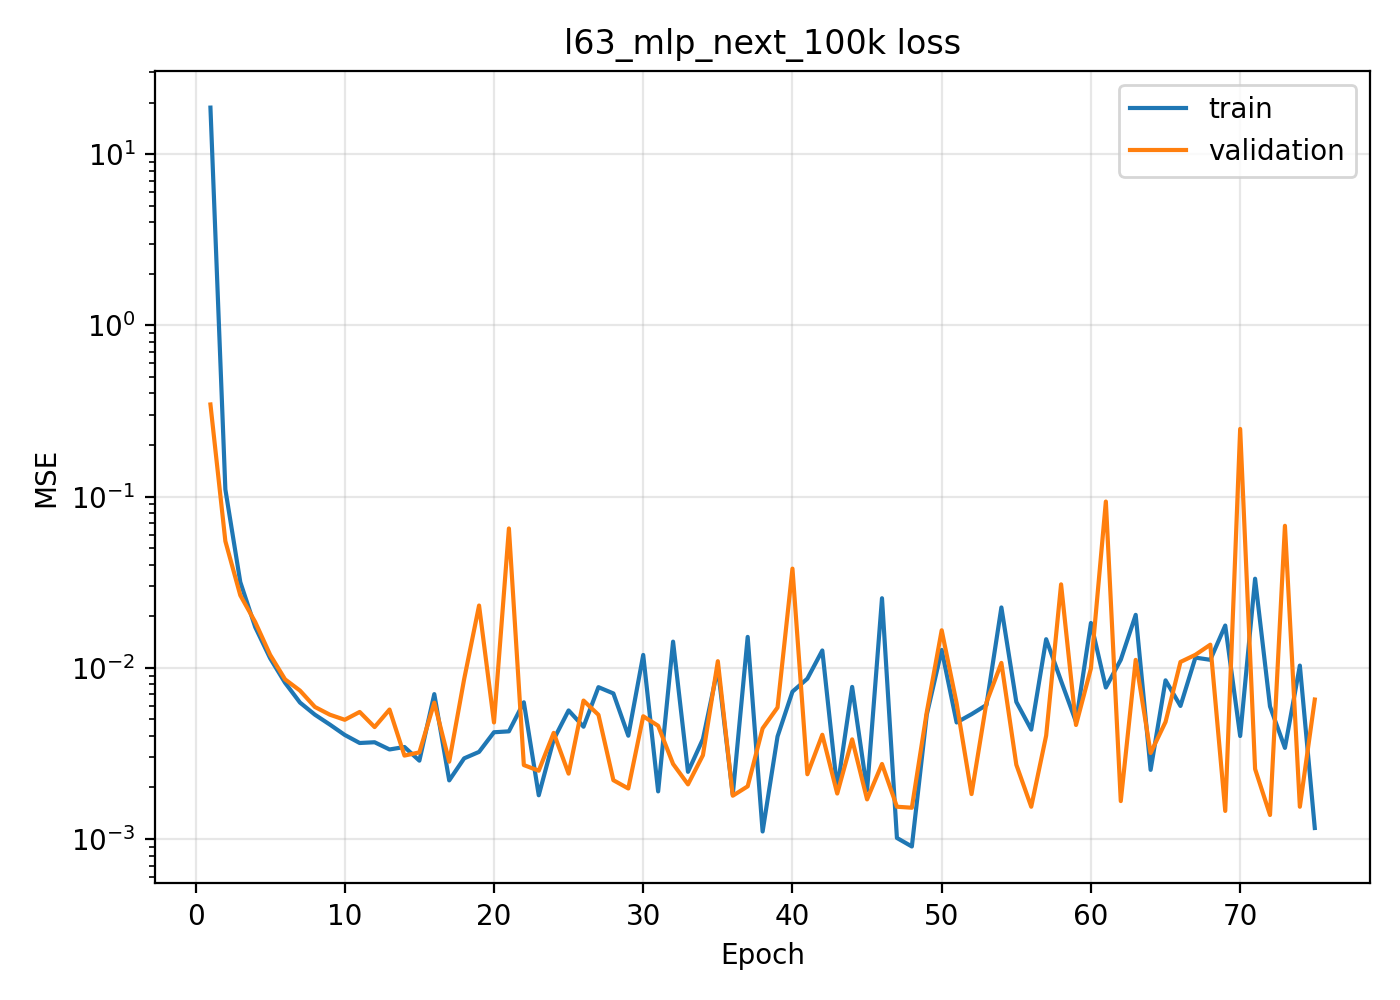

**figures/l63_mlp_tendency_100k_loss.png**

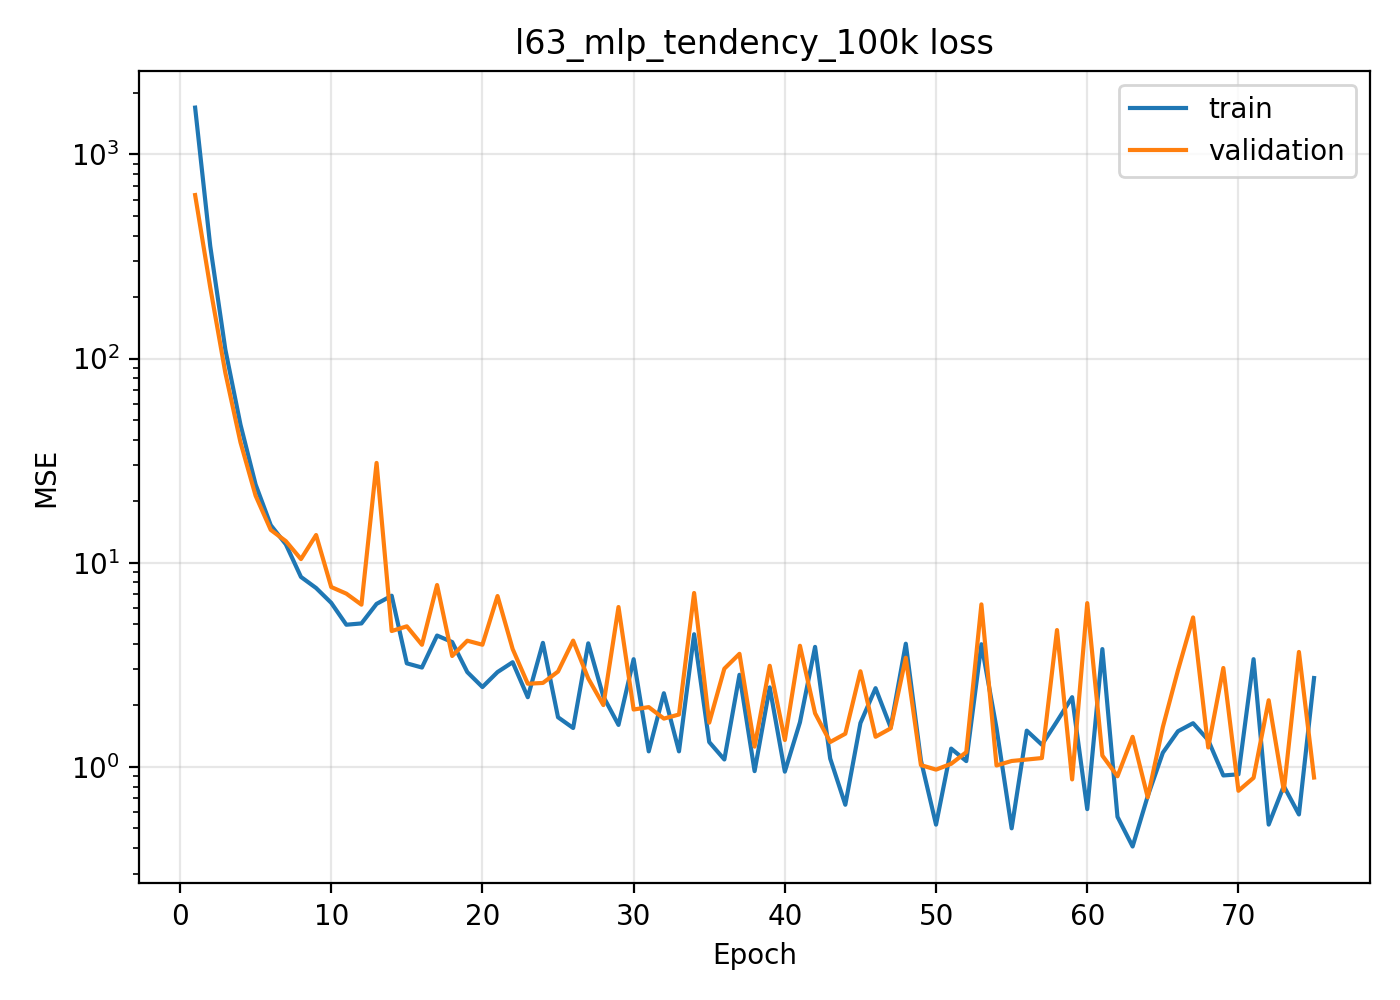

**figures/l63_cnn_next_100k_loss.png**

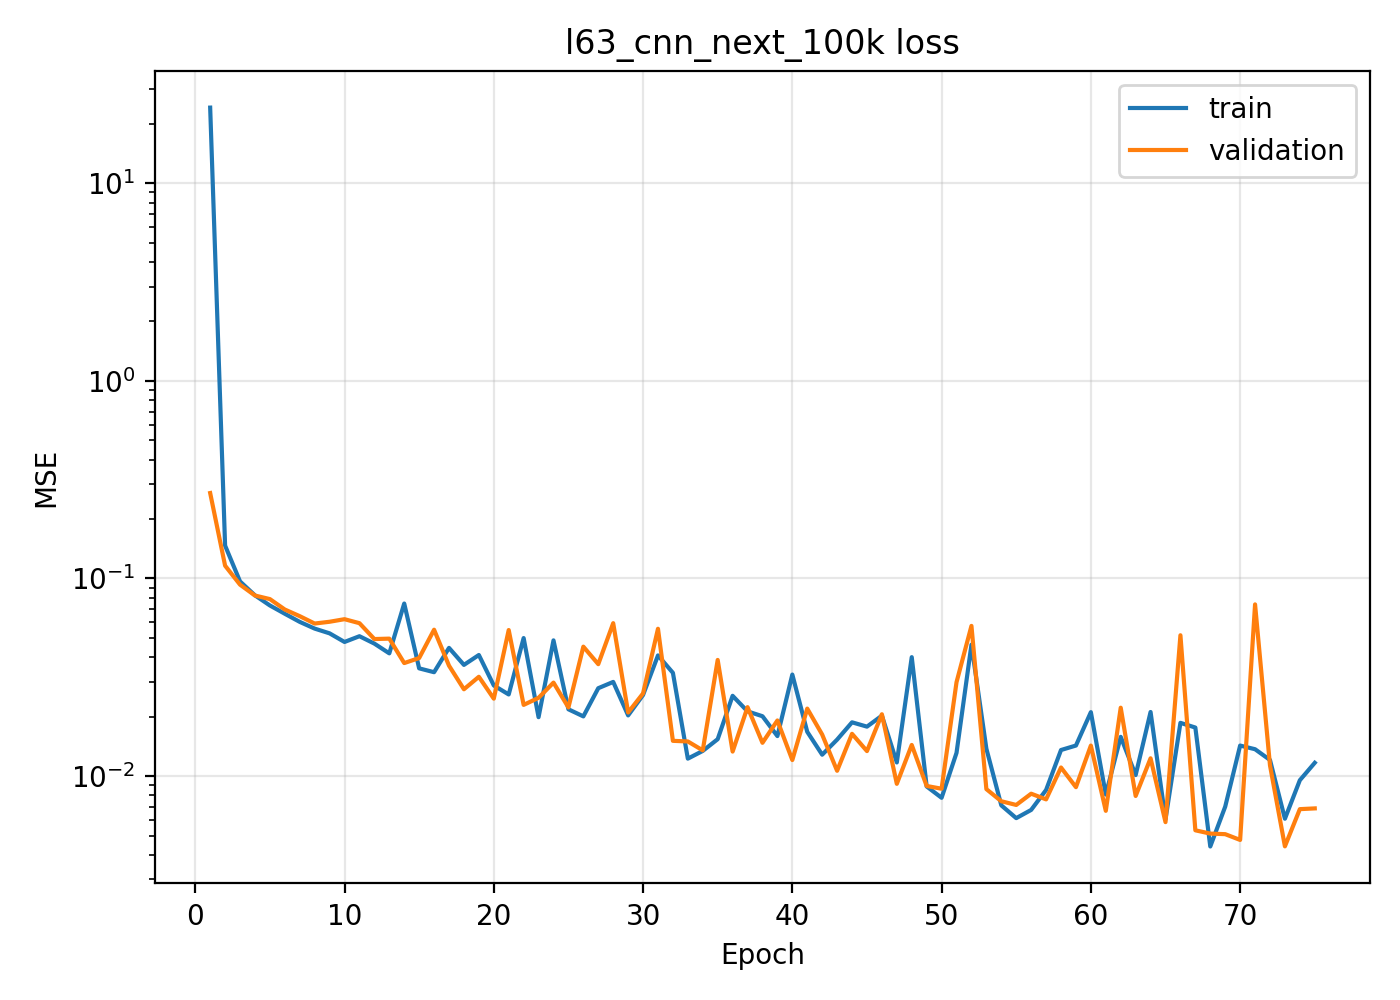

**figures/l63_cnn_tendency_100k_loss.png**

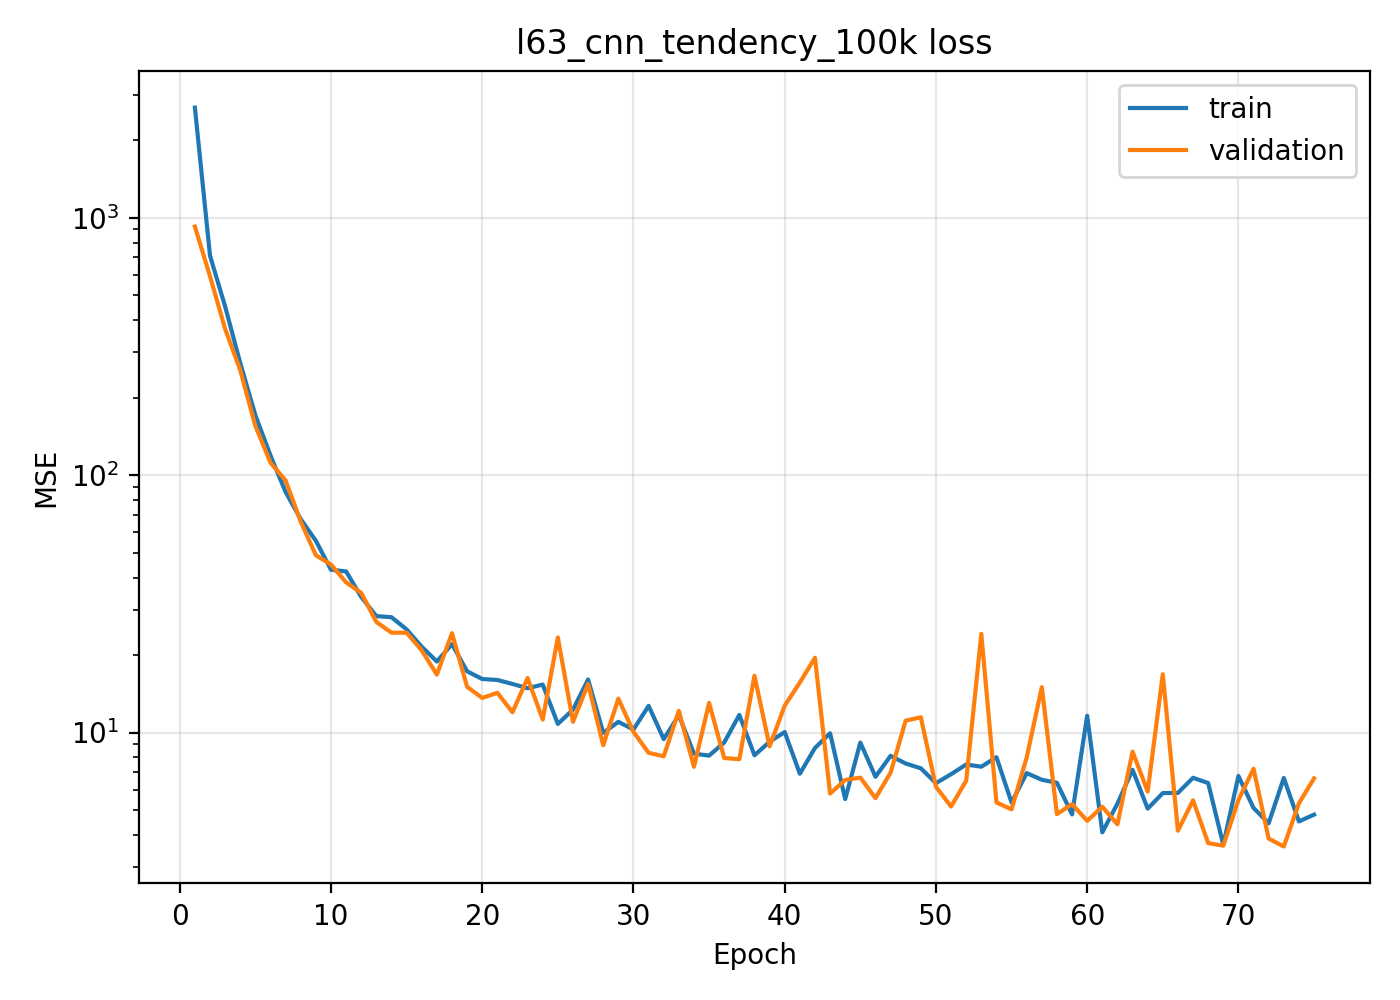

**figures/l96_mlp_next_100k_loss.png**

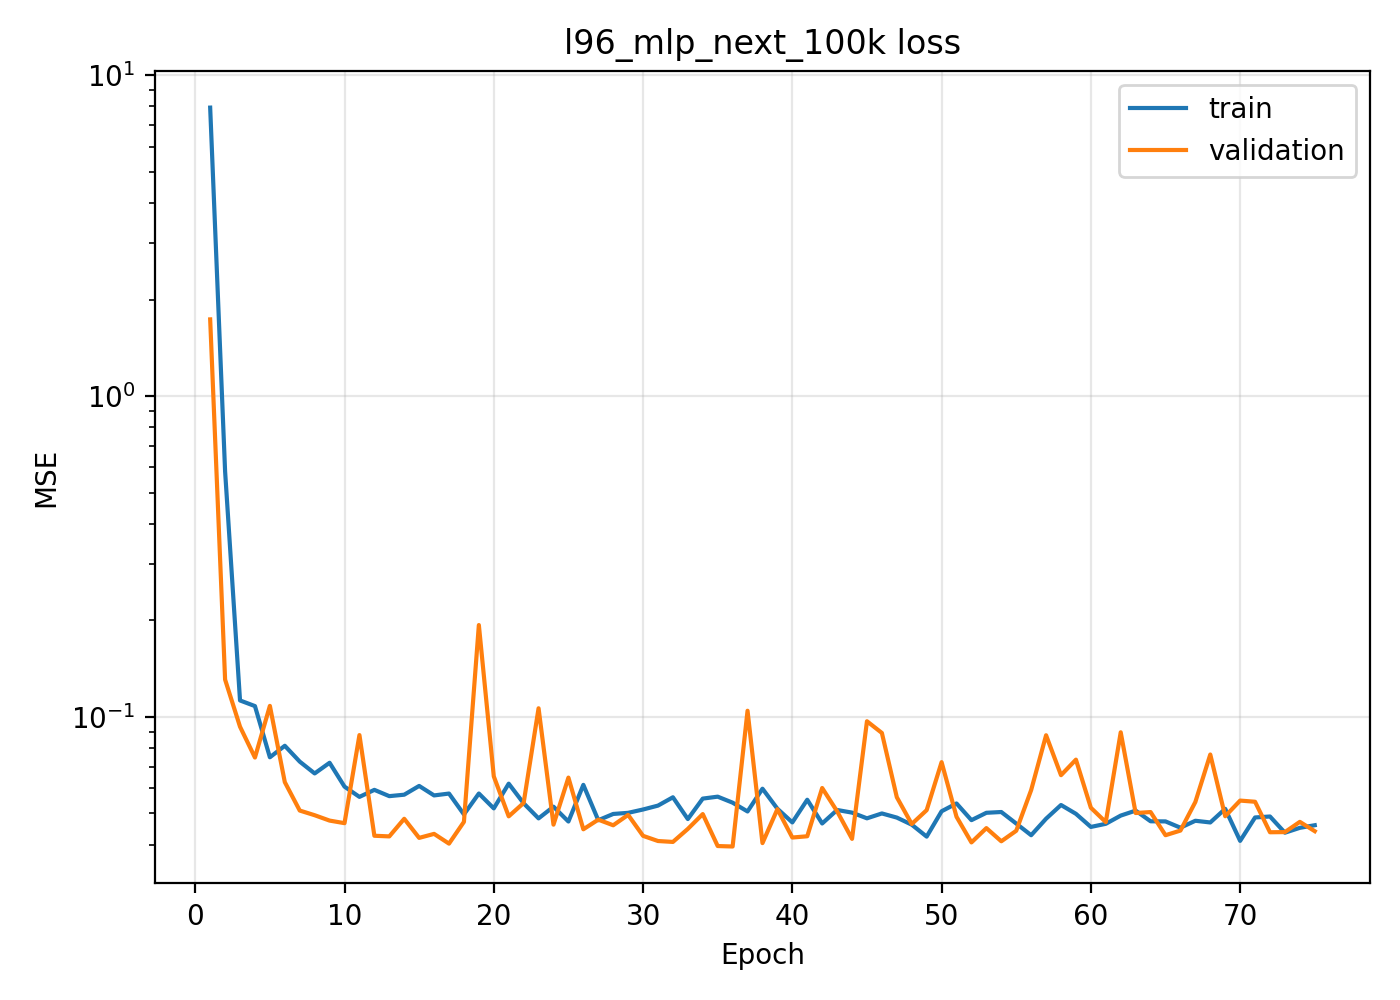

**figures/l96_mlp_tendency_100k_loss.png**

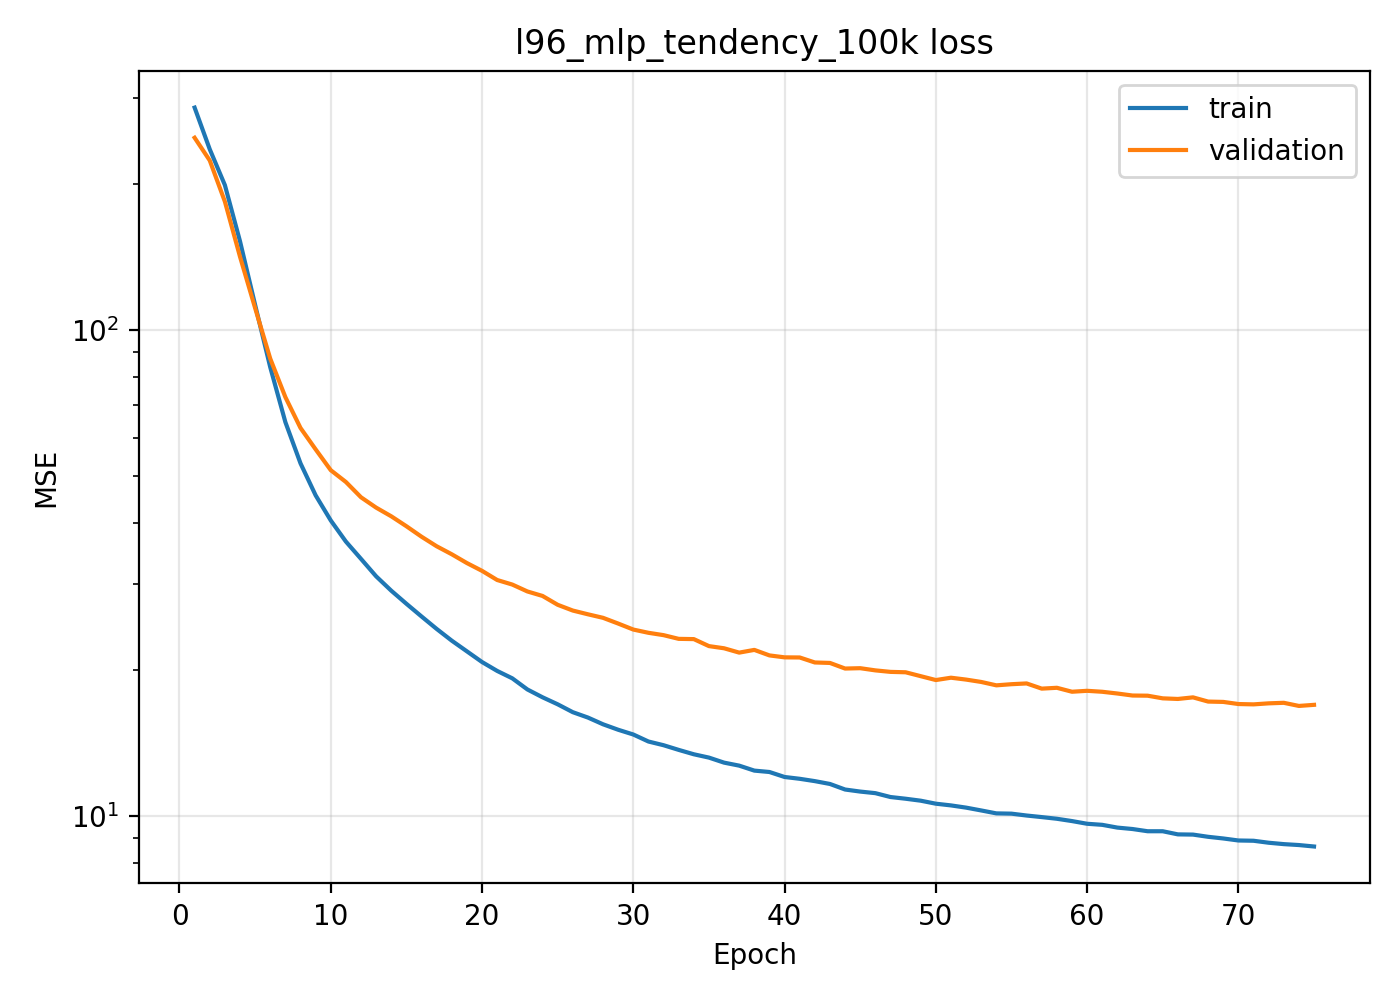

**figures/l96_cnn_next_100k_loss.png**

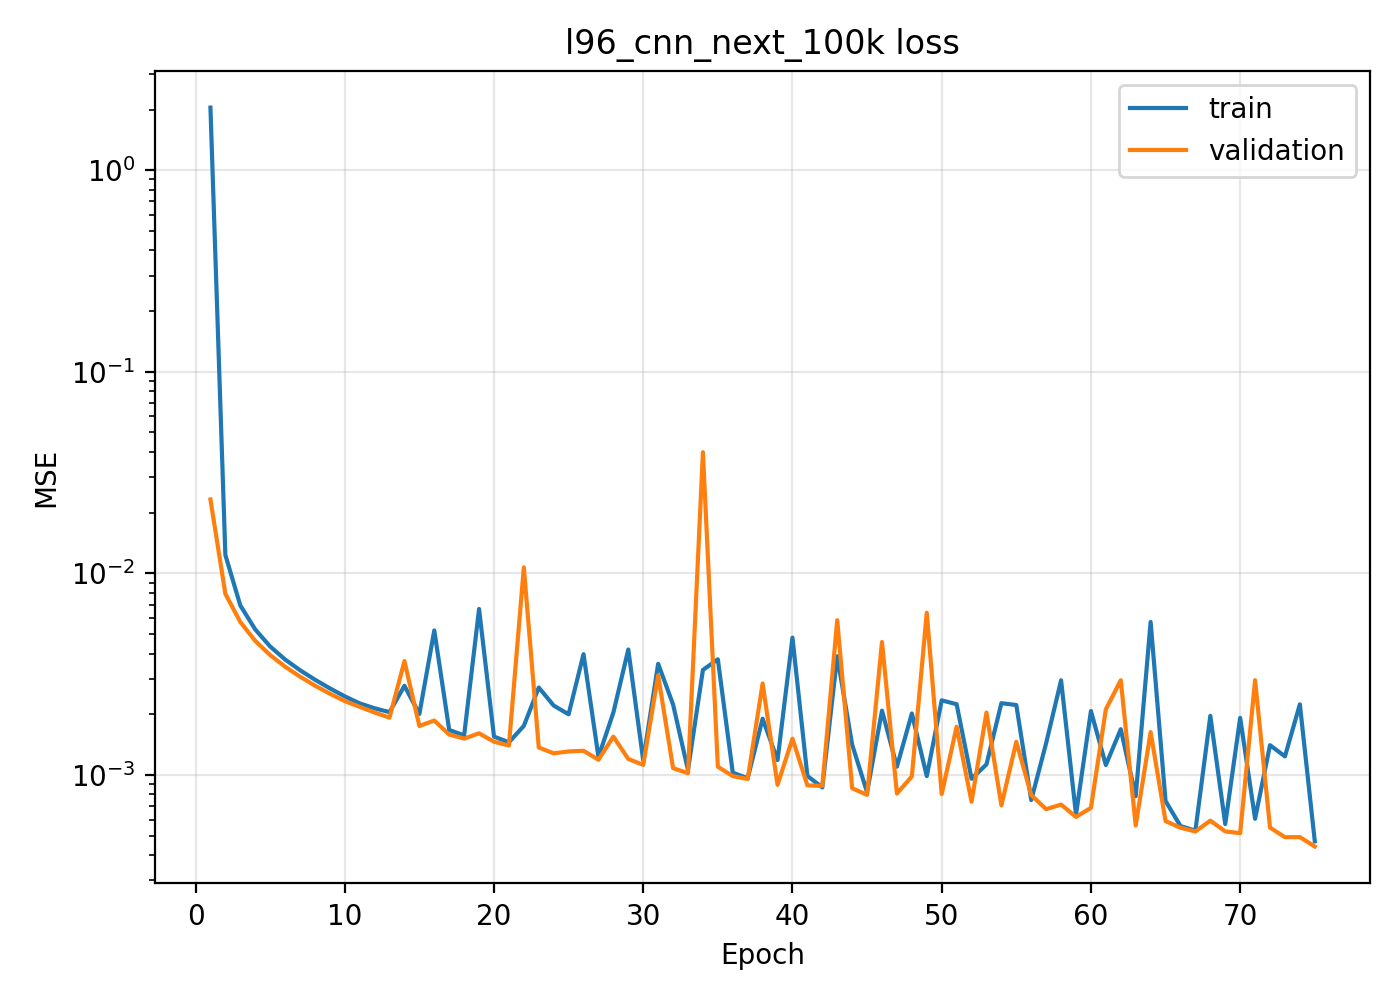

**figures/l96_cnn_tendency_100k_loss.png**

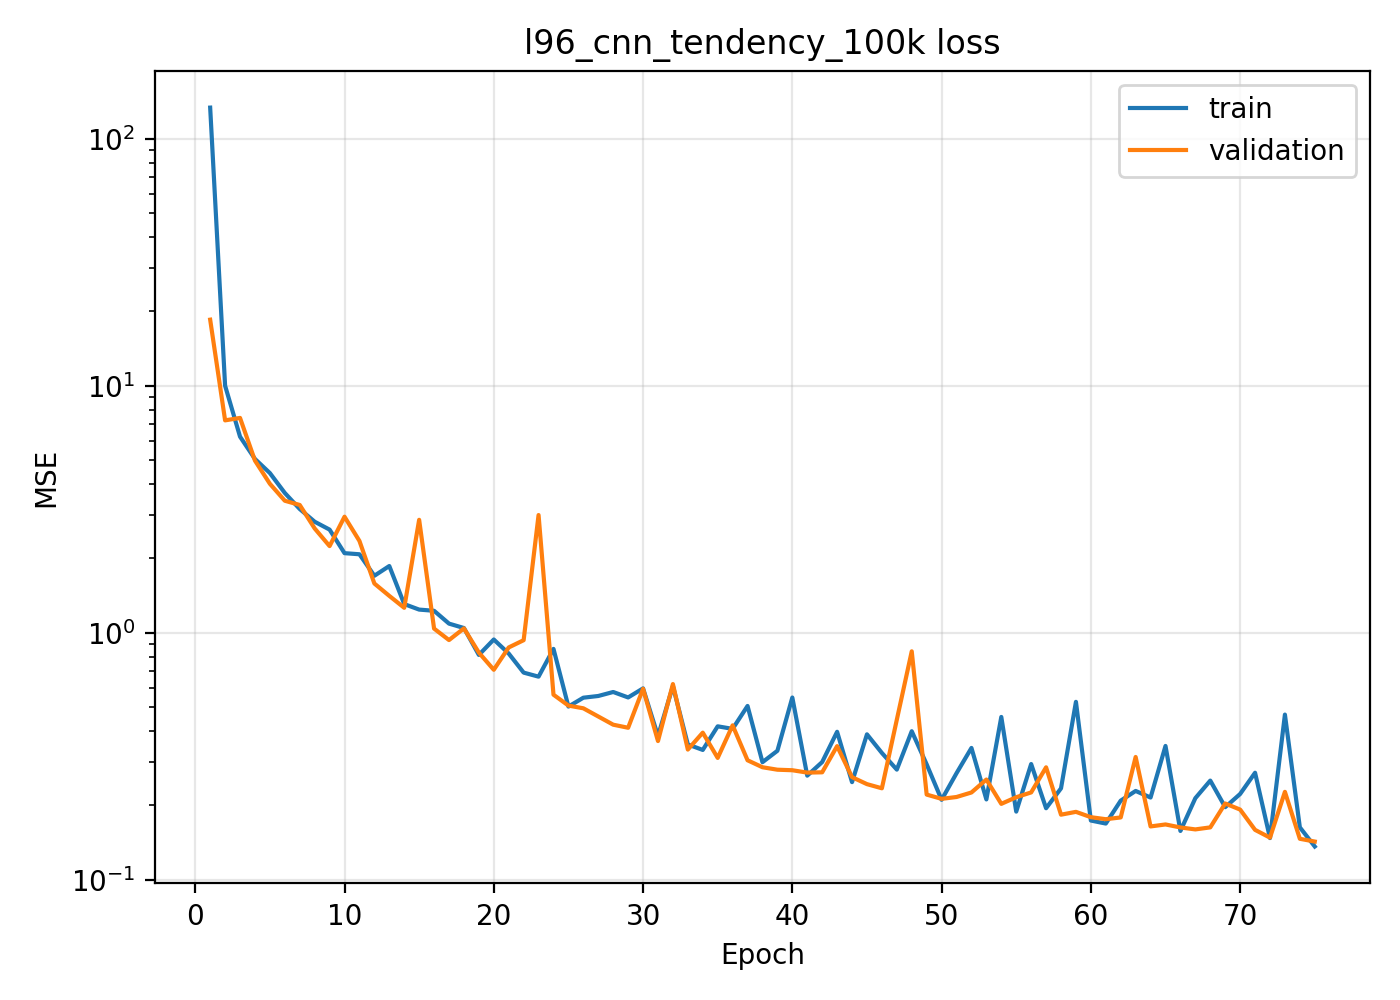

In [24]:
loss_figures = [
    'figures/l63_mlp_next_100k_loss.png',
    'figures/l63_mlp_tendency_100k_loss.png',
    'figures/l63_cnn_next_100k_loss.png',
    'figures/l63_cnn_tendency_100k_loss.png',
    'figures/l96_mlp_next_100k_loss.png',
    'figures/l96_mlp_tendency_100k_loss.png',
    'figures/l96_cnn_next_100k_loss.png',
    'figures/l96_cnn_tendency_100k_loss.png',
]
for fig in loss_figures:
    display(Markdown(f'**{fig}**'))
    show_image(fig, width=650)


## 4. Autoregressive rollout evaluation

Low one-step error is not sufficient in a chaotic system. The emulator is also rolled out autoregressively, feeding its own prediction back as the next input. This tests whether the learned model produces stable and physically plausible long-time dynamics.

The diagnostic is RMSE as a function of time, plus a prediction horizon defined as the first crossing of a threshold based on the test-set climatological variability.


In [25]:
rollout = read_csv(REPORTS / '13_rollout_100k_summary.csv')
display(rollout[['system','architecture','target','label','final_rmse','max_rmse','mean_rmse','prediction_horizon','horizon_step']])


,system,architecture,target,label,final_rmse,max_rmse,mean_rmse,prediction_horizon,horizon_step
0,L63,MLP,next,MLP_next,7.587706e+00,2.915396e+01,16.446724,0.80,80
1,L63,MLP,tendency,MLP_tendency,1.294555e+01,2.823252e+01,9.721099,2.61,261
2,L63,CNN,next,CNN_next,1.913177e+01,9.617625e+01,18.387466,0.87,87
3,L63,CNN,tendency,CNN_tendency,1.385539e+01,2.844848e+01,9.676715,0.92,92
4,L96,MLP,next,MLP_next,1.230811e+06,1.230811e+06,103866.492188,0.12,12
5,L96,MLP,tendency,MLP_tendency,5.805893e+00,7.051826e+00,5.232004,0.77,77
6,L96,CNN,next,CNN_next,4.874746e+00,6.386217e+00,4.984538,1.16,116
7,L96,CNN,tendency,CNN_tendency,4.078841e+00,7.035537e+00,4.994722,2.33,233


In [26]:
horizon = read_csv(REPORTS / '13_prediction_horizon_100k.csv')
horizon['horizon_over_doubling_time'] = horizon['prediction_horizon'] / horizon['physical_doubling_time']
display(horizon[['system','label','prediction_horizon','physical_doubling_time','horizon_over_doubling_time']])


,system,label,prediction_horizon,physical_doubling_time,horizon_over_doubling_time
0,L63,MLP_next,0.80,1.098901,0.7280
1,L63,MLP_tendency,2.61,1.098901,2.3751
2,L63,CNN_next,0.87,1.098901,0.7917
3,L63,CNN_tendency,0.92,1.098901,0.8372
4,L96,MLP_next,0.12,0.595238,0.2016
5,L96,MLP_tendency,0.77,0.595238,1.2936
6,L96,CNN_next,1.16,0.595238,1.9488
7,L96,CNN_tendency,2.33,0.595238,3.9144


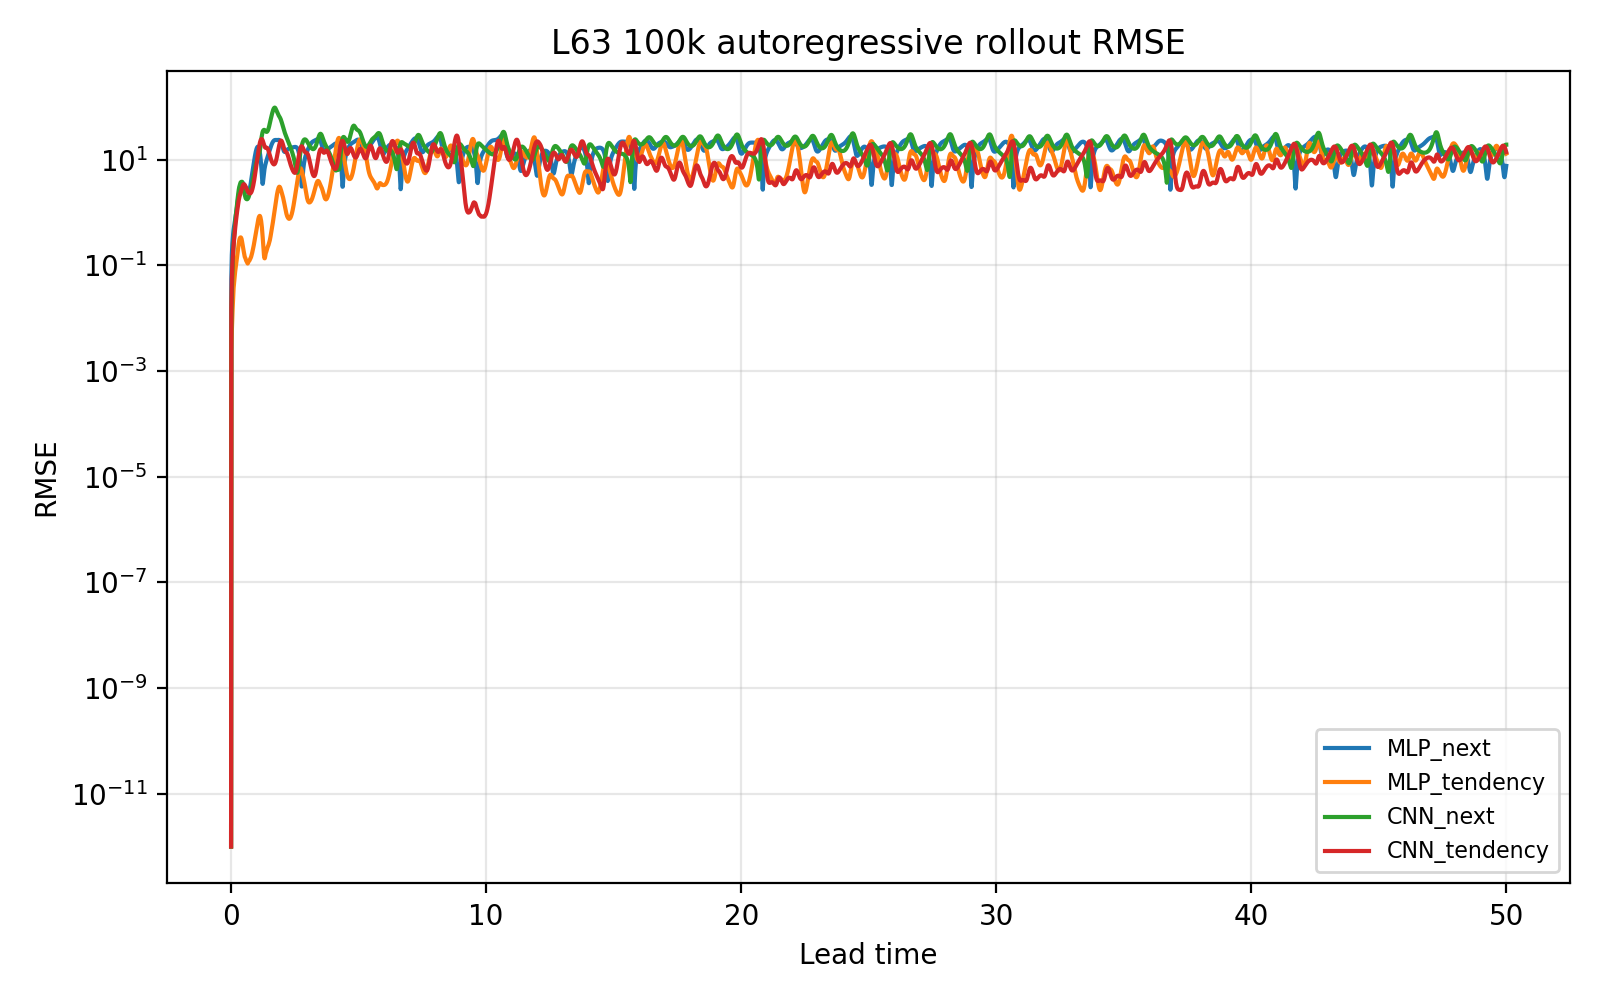

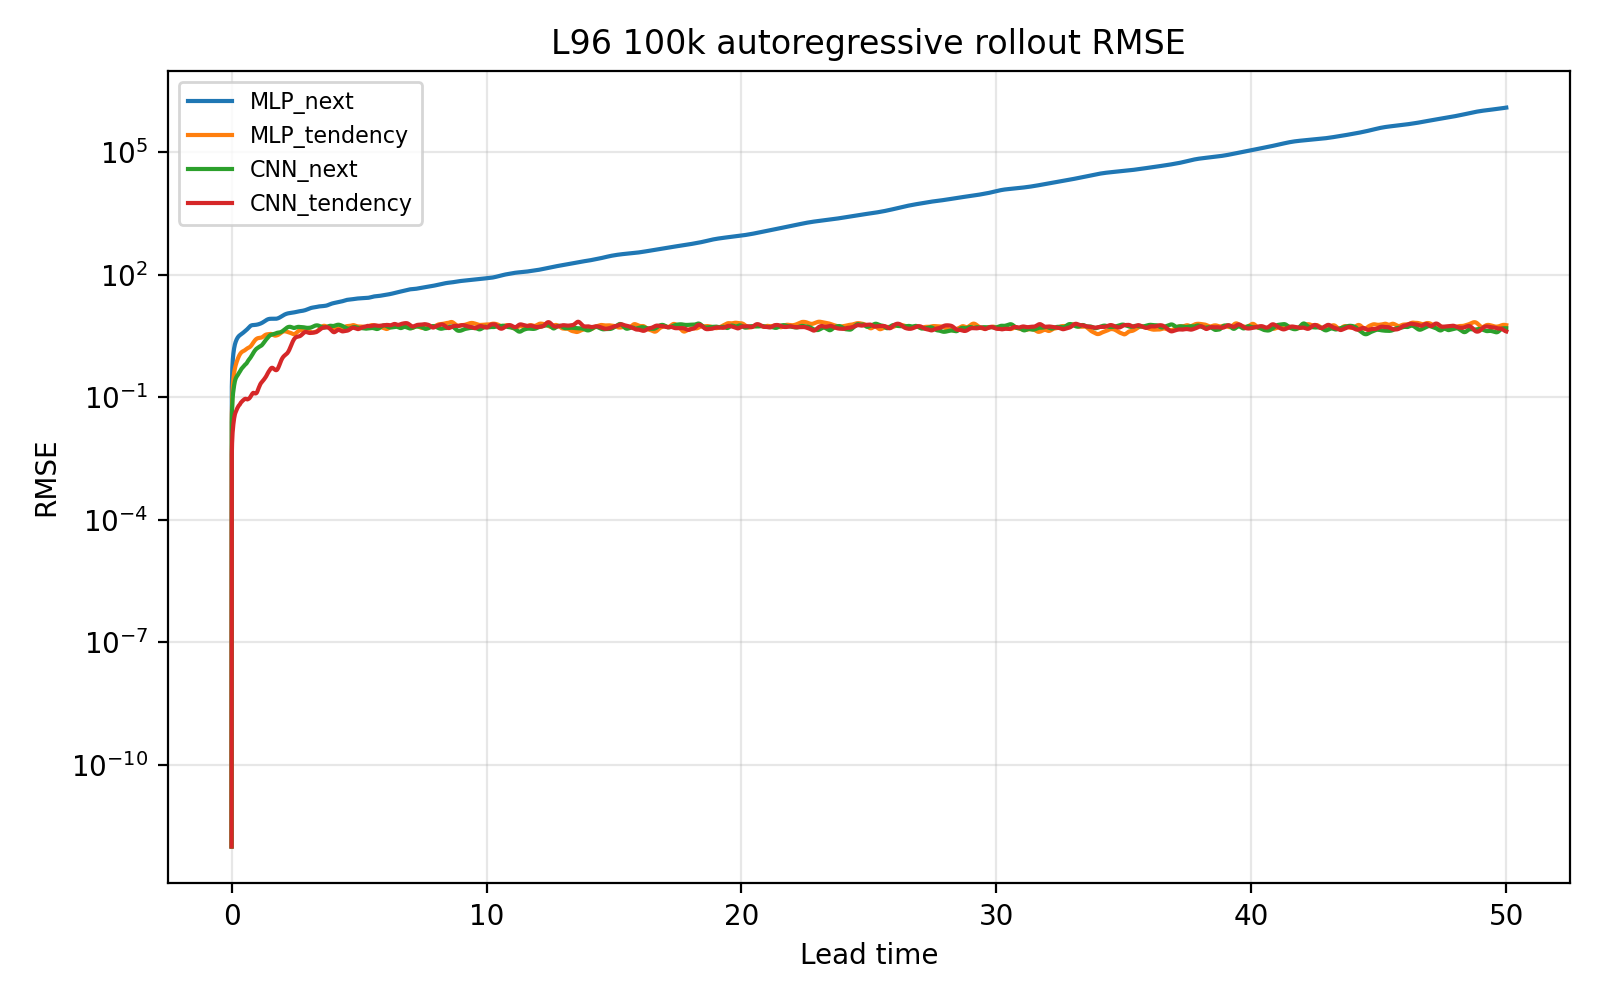

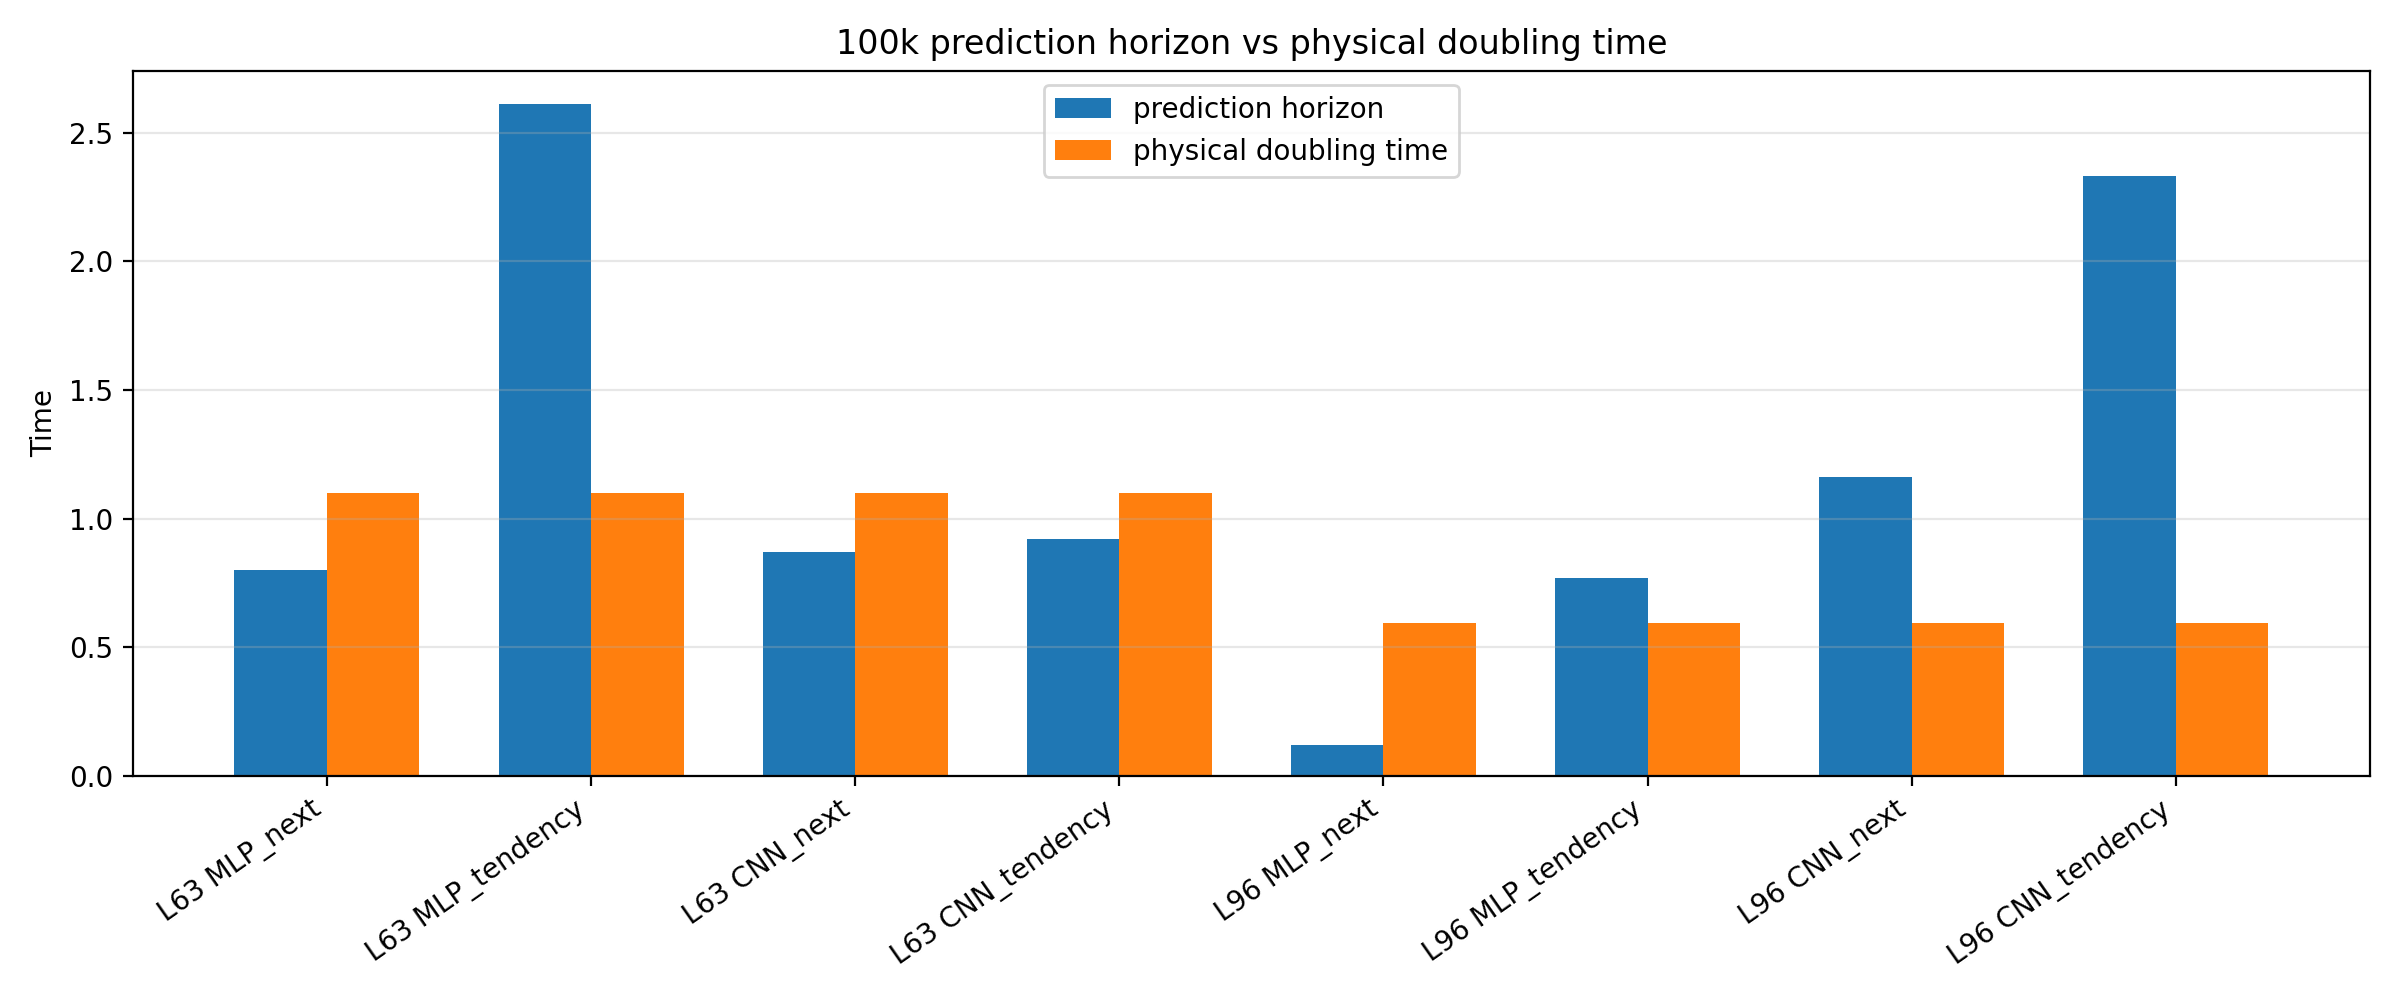

In [27]:
show_image('figures/l63_100k_rollout_rmse_all.png', width=850)
show_image('figures/l96_100k_rollout_rmse_all.png', width=850)
show_image('figures/13_prediction_horizon_100k.png', width=850)


### Rollout interpretation

The main qualitative result is that tendency learning and the periodic CNN inductive bias improve autoregressive behavior, especially for Lorenz-96. The direct next-state MLP can have reasonable one-step error but becomes unstable when rolled out repeatedly.

This is an important negative result: **one-step supervised accuracy does not guarantee a dynamically faithful emulator**.


## 5. Attractor and spectral diagnostics

Autoregressive rollouts are also compared by inspecting representative trajectories and power spectra. Spectral diagnostics test whether the emulator reproduces the characteristic temporal variability, not only pointwise RMSE.


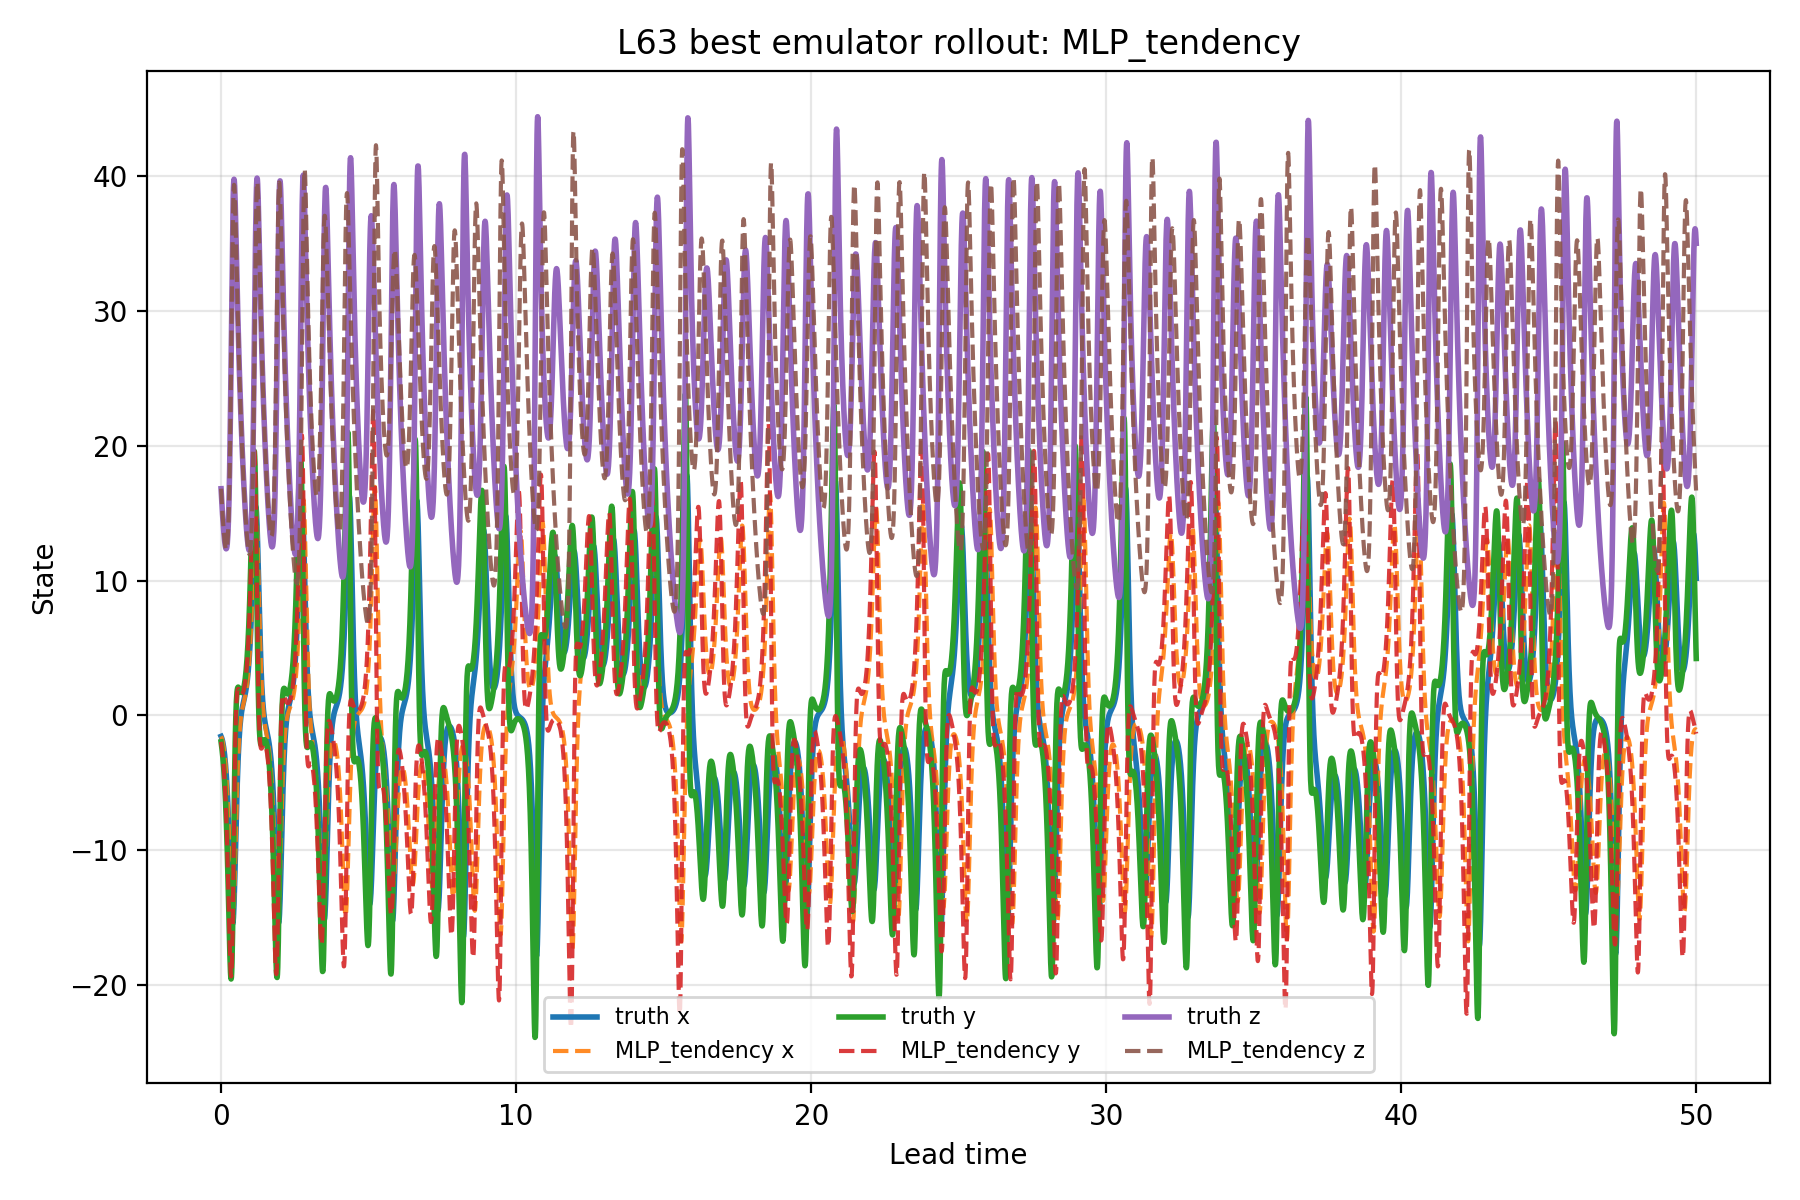

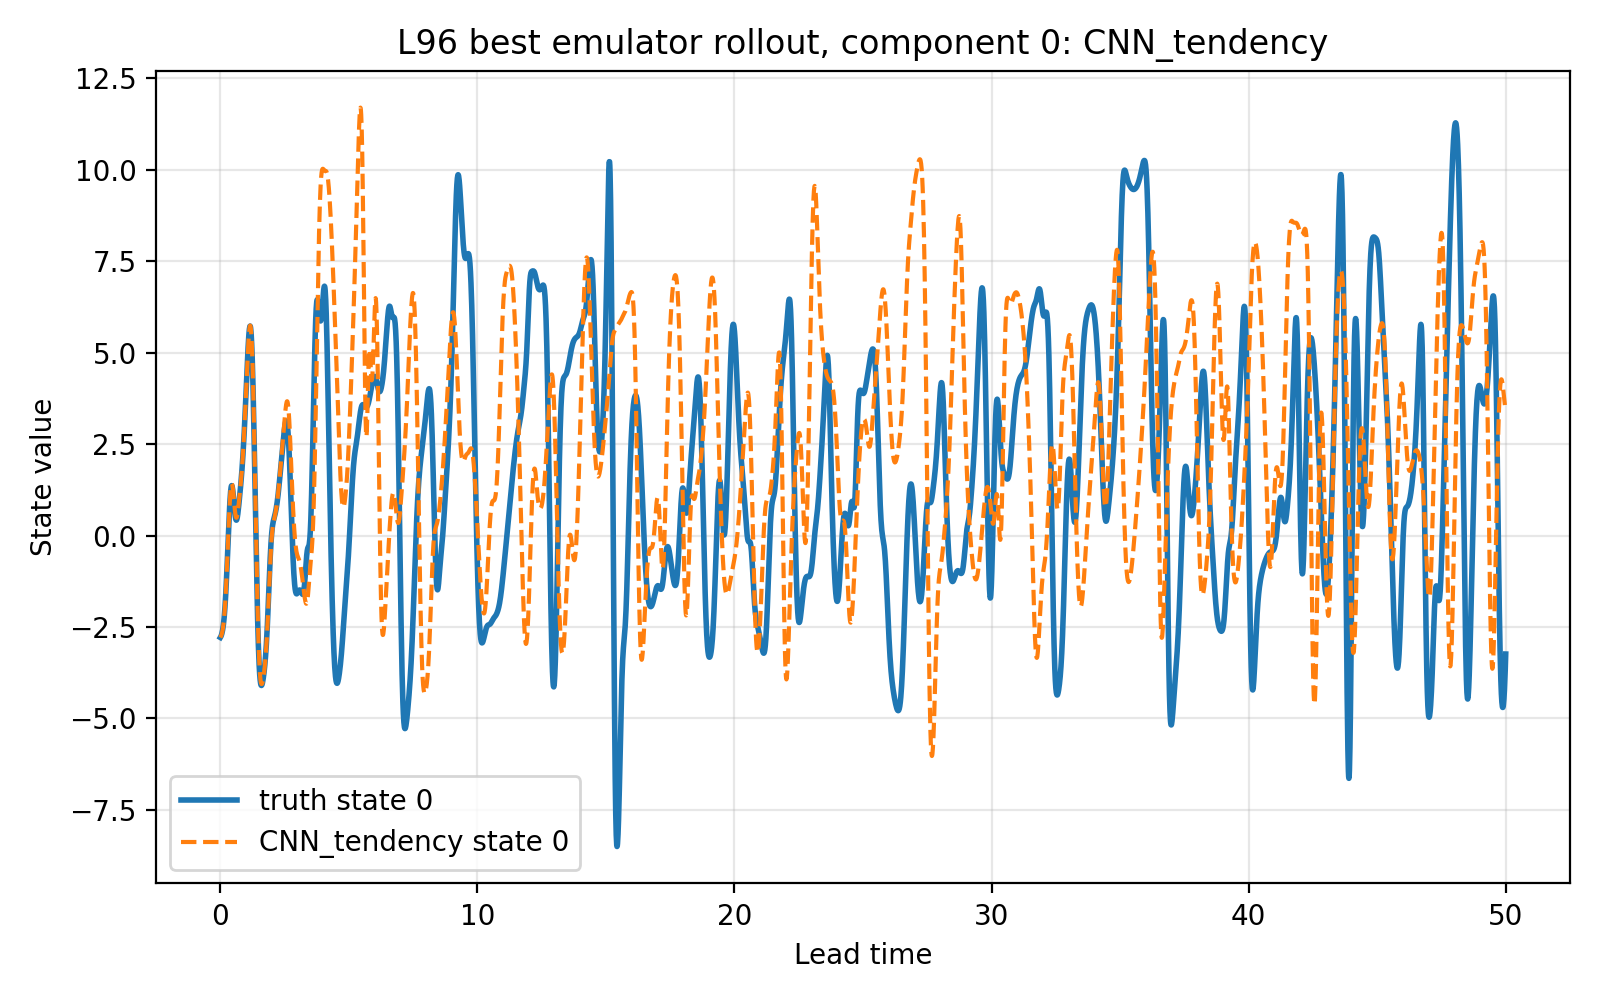

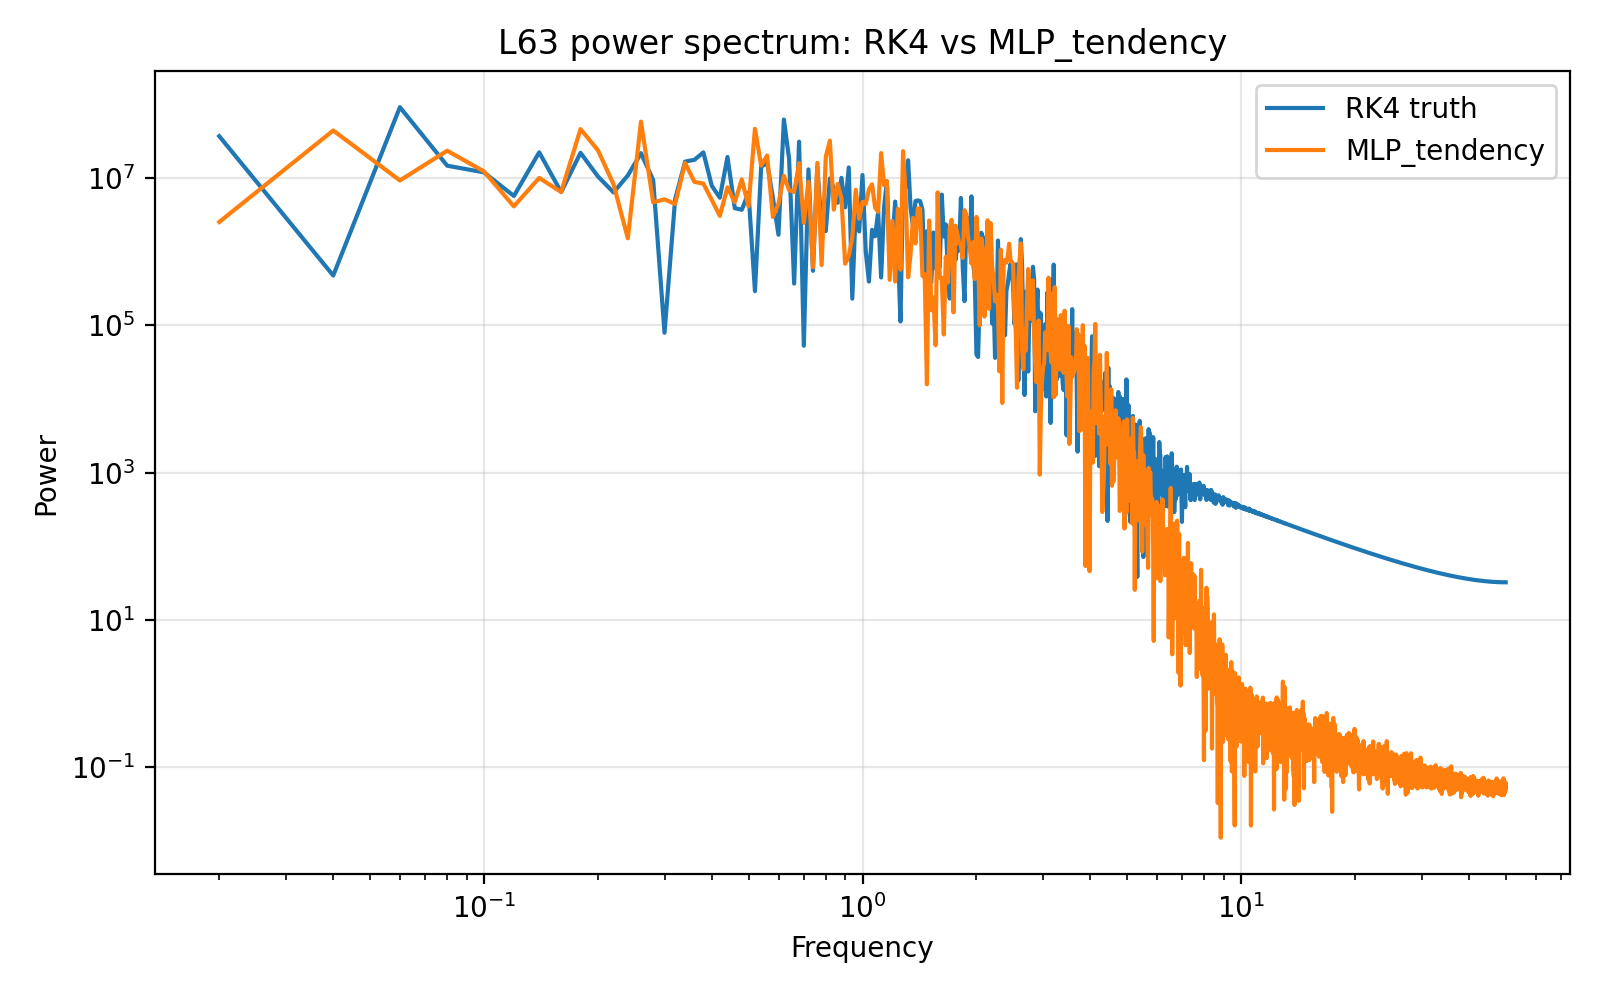

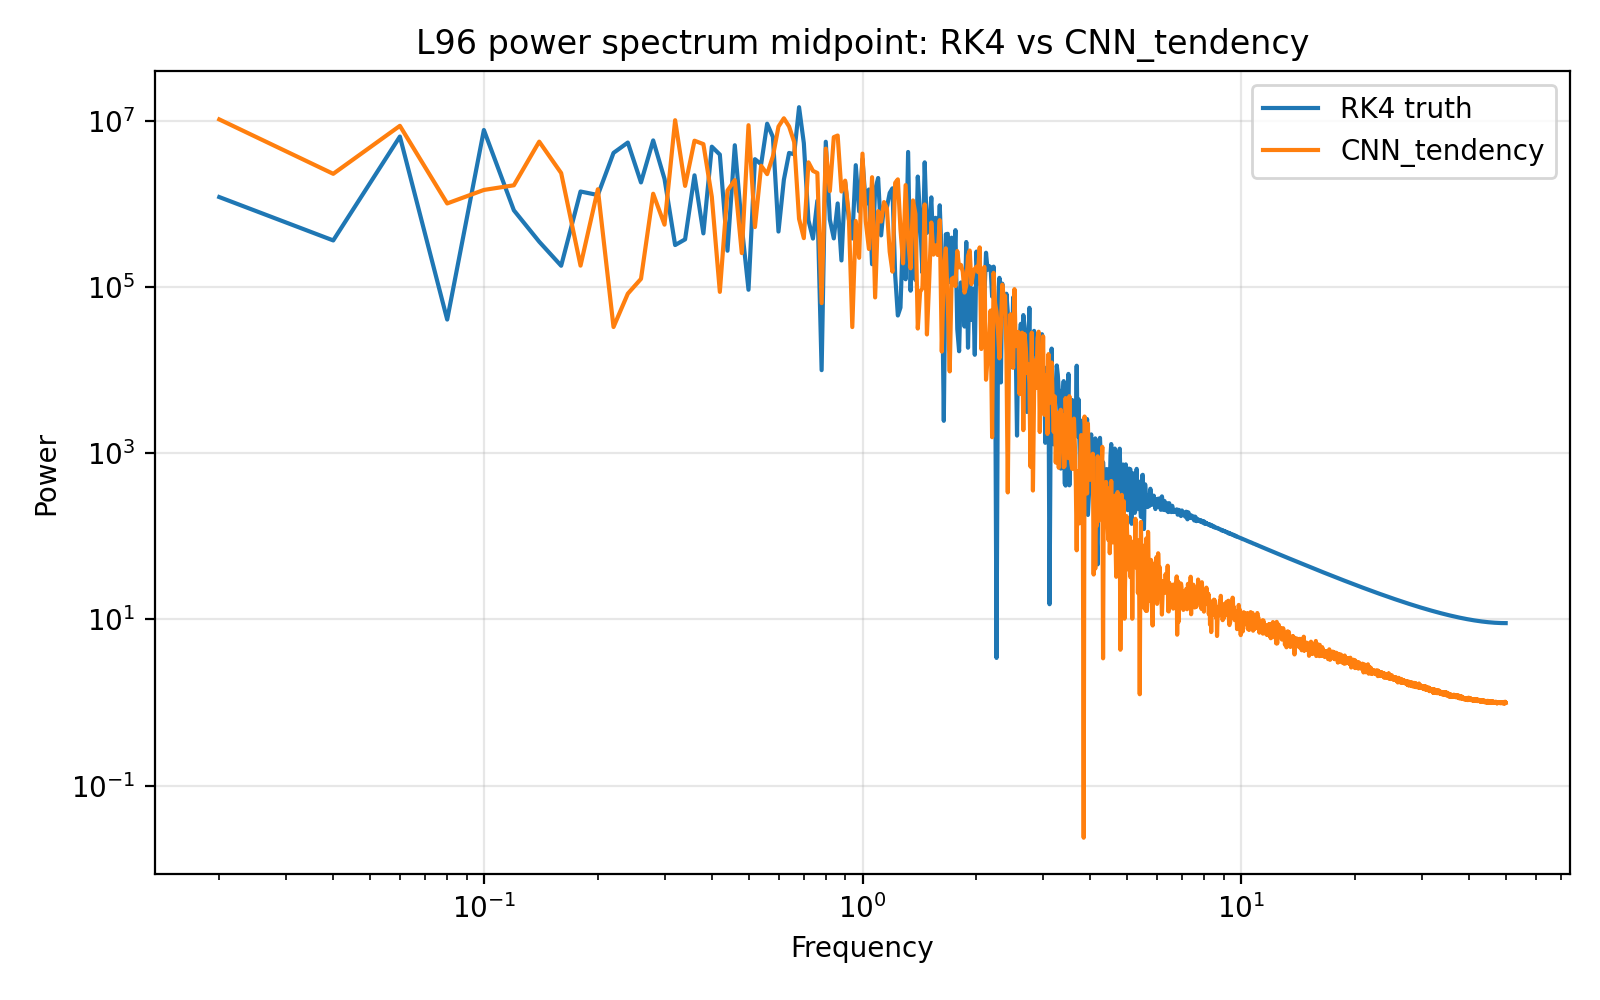

In [28]:
show_image('figures/l63_100k_best_rollout_xyz.png', width=850)
show_image('figures/l96_100k_best_rollout_state0.png', width=850)
show_image('figures/l63_100k_power_spectrum_best.png', width=850)
show_image('figures/l96_100k_power_spectrum_best.png', width=850)


In [29]:
print(read_text(REPORTS / '13_rollout_100k_summary.txt'))


100K AUTOREGRESSIVE ROLLOUT SUMMARY
device = cuda
gpu = NVIDIA A100-PCIE-40GB
rollout_steps = 5000
dt = 0.01

system,label,final_rmse,max_rmse,mean_rmse,prediction_horizon,horizon_step
L63,MLP_next,7.58770609e+00,2.91539612e+01,1.64467239e+01,7.99999982e-01,80
L63,MLP_tendency,1.29455452e+01,2.82325153e+01,9.72109890e+00,2.60999994e+00,261
L63,CNN_next,1.91317749e+01,9.61762466e+01,1.83874664e+01,8.69999981e-01,87
L63,CNN_tendency,1.38553915e+01,2.84484825e+01,9.67671490e+00,9.19999979e-01,92
L96,MLP_next,1.23081062e+06,1.23081062e+06,1.03866492e+05,1.19999997e-01,12
L96,MLP_tendency,5.80589294e+00,7.05182600e+00,5.23200369e+00,7.69999983e-01,77
L96,CNN_next,4.87474585e+00,6.38621664e+00,4.98453808e+00,1.15999997e+00,116
L96,CNN_tendency,4.07884121e+00,7.03553677e+00,4.99472189e+00,2.32999995e+00,233

Best one-step models used for power spectra
------------------------------------------------------------------------------
L63 best = MLP_tendency
L96 best = CNN_tendency

Power-spectrum 

## 6. Leading Lyapunov exponents

The leading Lyapunov exponent \(\lambda_1\) measures asymptotic exponential separation of nearby trajectories. It is estimated with autograd Jacobians and QR tangent propagation for the learned maps. The physical Lorenz-63 value is also estimated with RK4; Lorenz-96 is compared to the known reference value.

Reference values used:

- Lorenz-63: \(\lambda_1 \approx 0.91\)
- Lorenz-96 \((N=40,F=8)\): \(\lambda_1 \approx 1.68\)


In [30]:
lyap = read_csv(REPORTS / '14_lyapunov_100k_table.csv')
lyap['abs_error'] = (lyap['lambda1'] - lyap['reference_lambda']).abs()
display(lyap[['system','label','lambda1','reference_lambda','abs_error','n_steps']])


,system,label,lambda1,reference_lambda,abs_error,n_steps
0,L63,L63_physical_RK4,0.917680,0.91,0.007680,1000
1,L96,L96_reference,1.680000,1.68,0.000000,0
2,L63,L63_MLP_next,-0.007593,0.91,0.917593,1000
3,L63,L63_MLP_tendency,0.707845,0.91,0.202155,1000
4,L63,L63_CNN_next,0.611544,0.91,0.298456,1000
5,L63,L63_CNN_tendency,1.197669,0.91,0.287669,1000
6,L96,L96_MLP_next,0.299141,1.68,1.380859,500
7,L96,L96_MLP_tendency,1.512843,1.68,0.167157,500
8,L96,L96_CNN_next,1.808328,1.68,0.128328,500
9,L96,L96_CNN_tendency,1.515213,1.68,0.164787,500


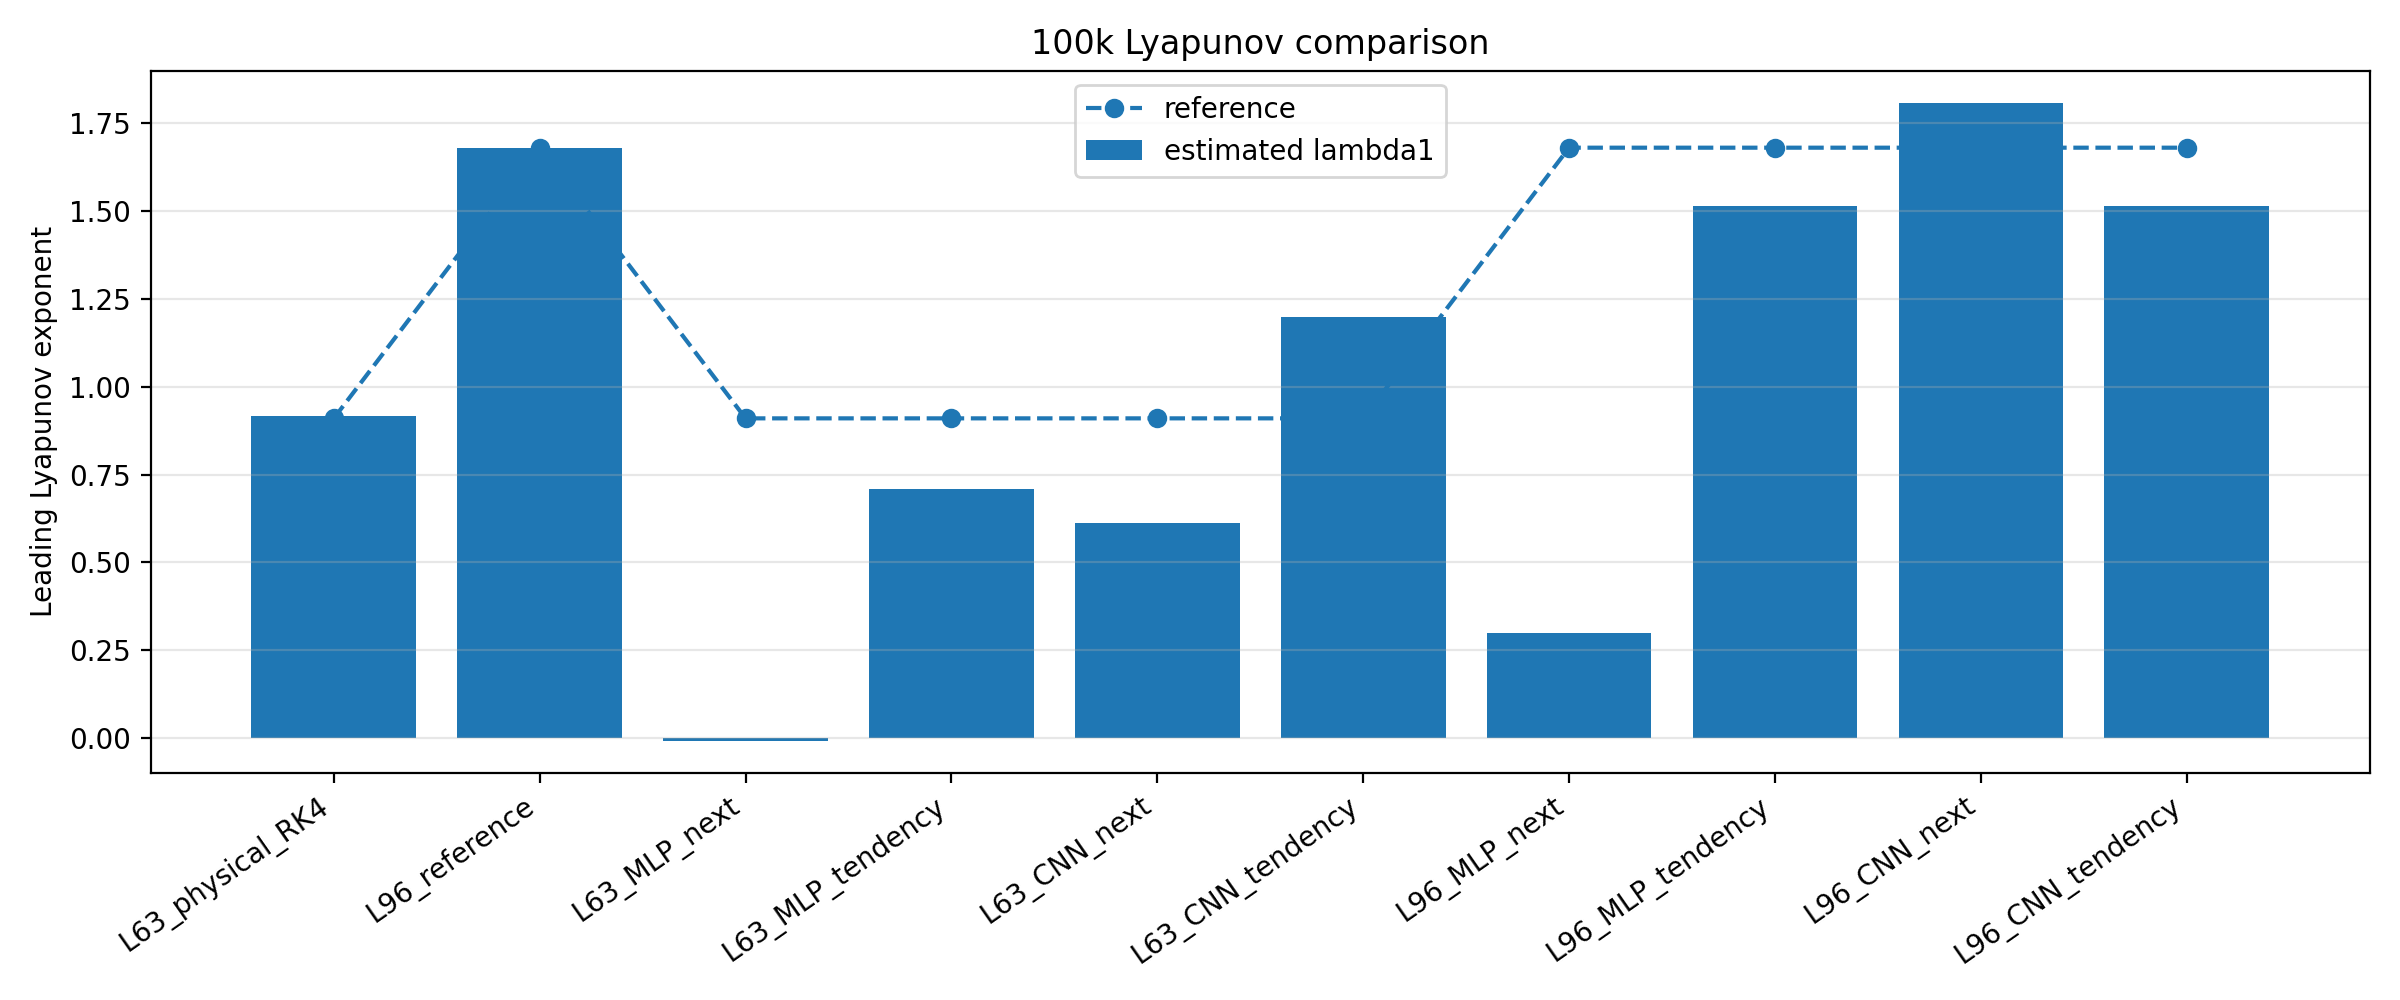

In [31]:
show_image('figures/14_lyapunov_100k_bar.png', width=900)


### Lyapunov interpretation

The Lyapunov table separates short-term fitting from dynamical fidelity. Models that are stable in rollout tend to be closer to the physical Lyapunov scale, while unstable or overly dissipative models produce poor \(\lambda_1\). The Lorenz-96 MLP next-state model is a clear example of failure: it diverges in rollout and strongly underestimates the reference Lyapunov exponent.


## 7. Finite-time Lyapunov exponents on the L63 attractor

The finite-time Lyapunov exponent (FTLE) measures local instability over finite windows. Unlike the global leading Lyapunov exponent, FTLEs depend on the current region of phase space. This makes FTLEs a more stringent test of whether the emulator reproduces where the physical system is locally unstable.


In [32]:
ftle = read_csv(REPORTS / '14_ftle_l63_100k_summary.csv')
display(ftle)


,model,mean,std,min,max,bias_vs_physical,mae_vs_physical,rmse_vs_physical,corr_vs_physical
0,physical,0.894520,0.937911,-0.727435,3.603590,0.000000,0.000000,0.000000,1.000000
1,mlp_tendency,2.222303,1.162162,0.069176,5.972736,1.327783,1.534586,1.836378,0.284871
2,cnn_tendency,2.189700,1.451426,-0.660846,8.953990,1.295180,1.618798,2.076903,0.128654


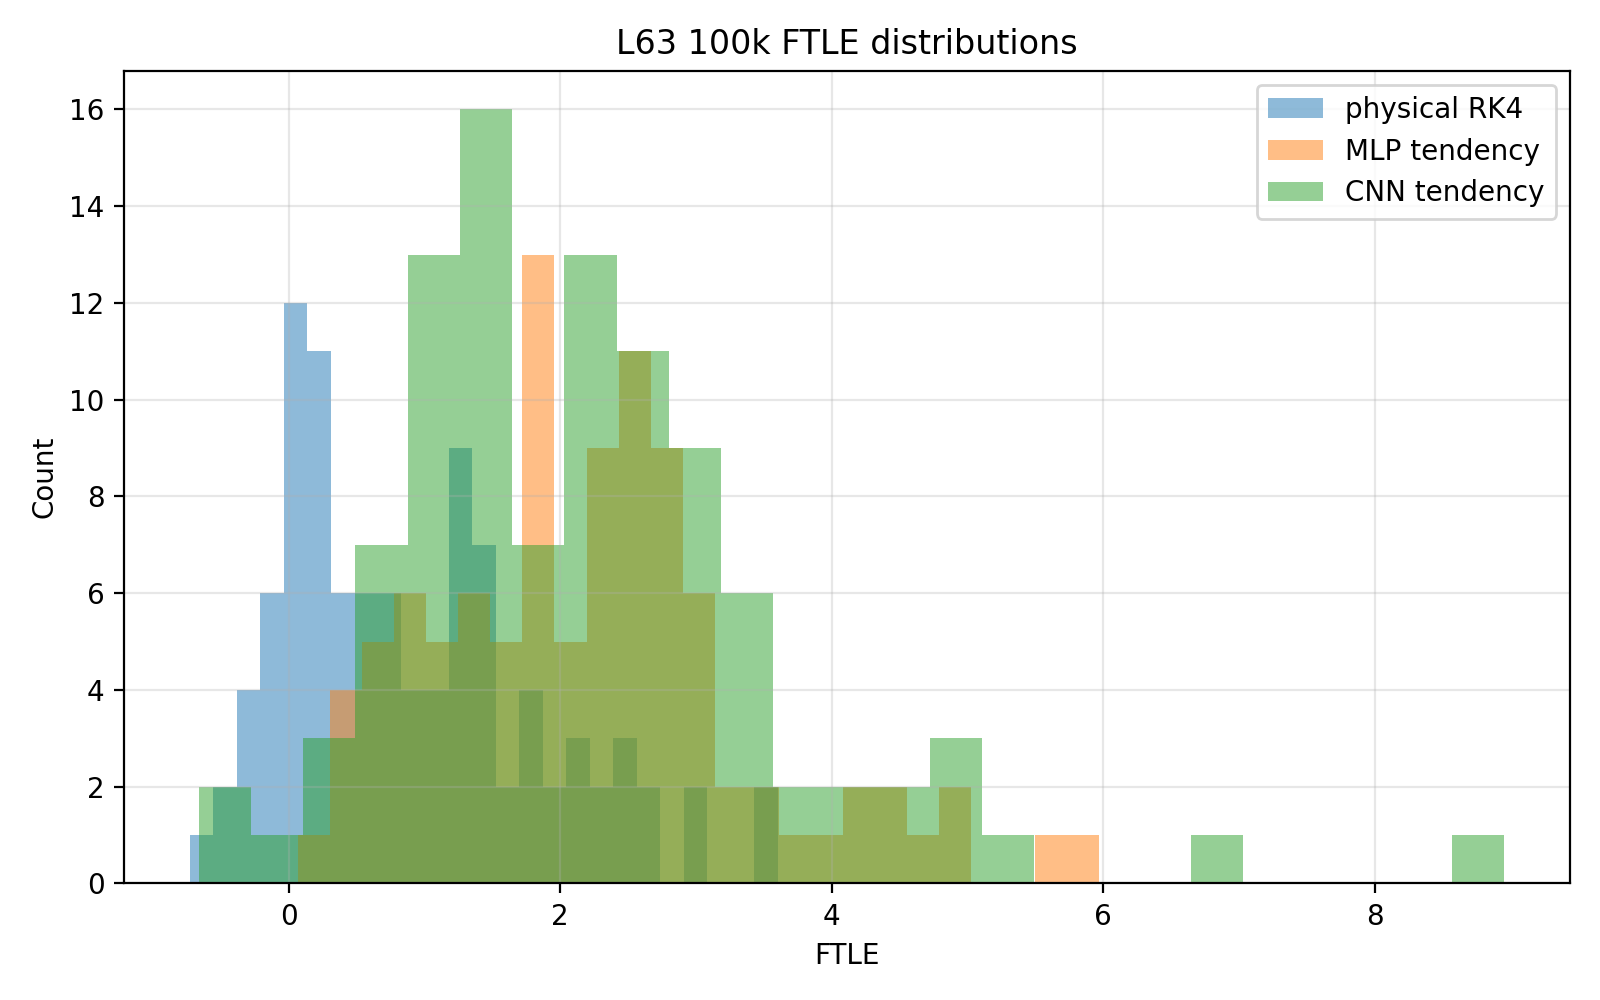

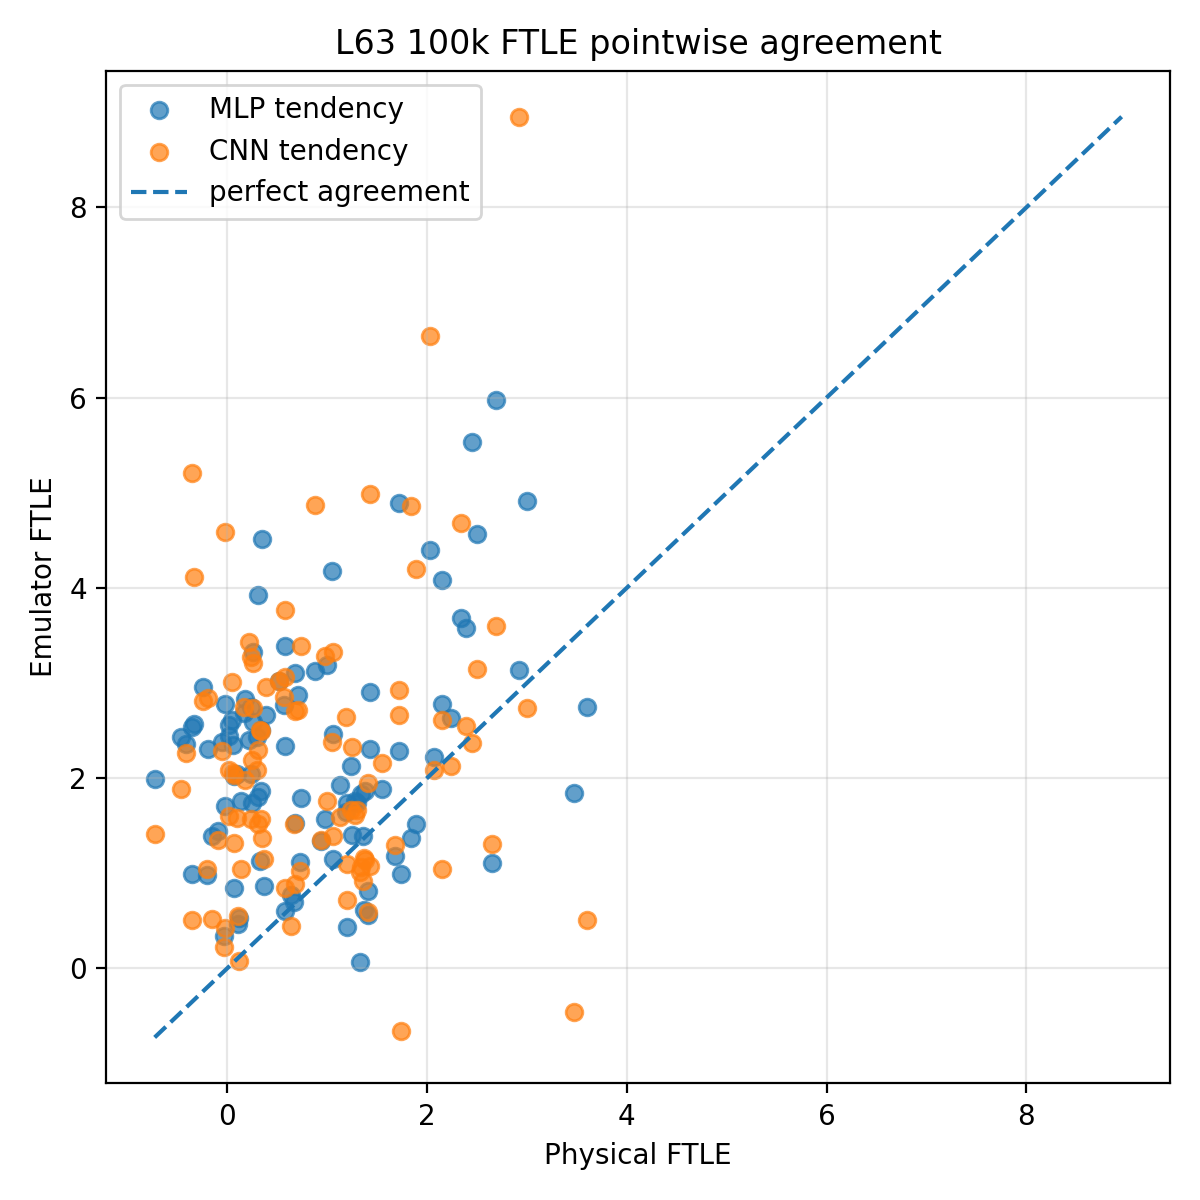

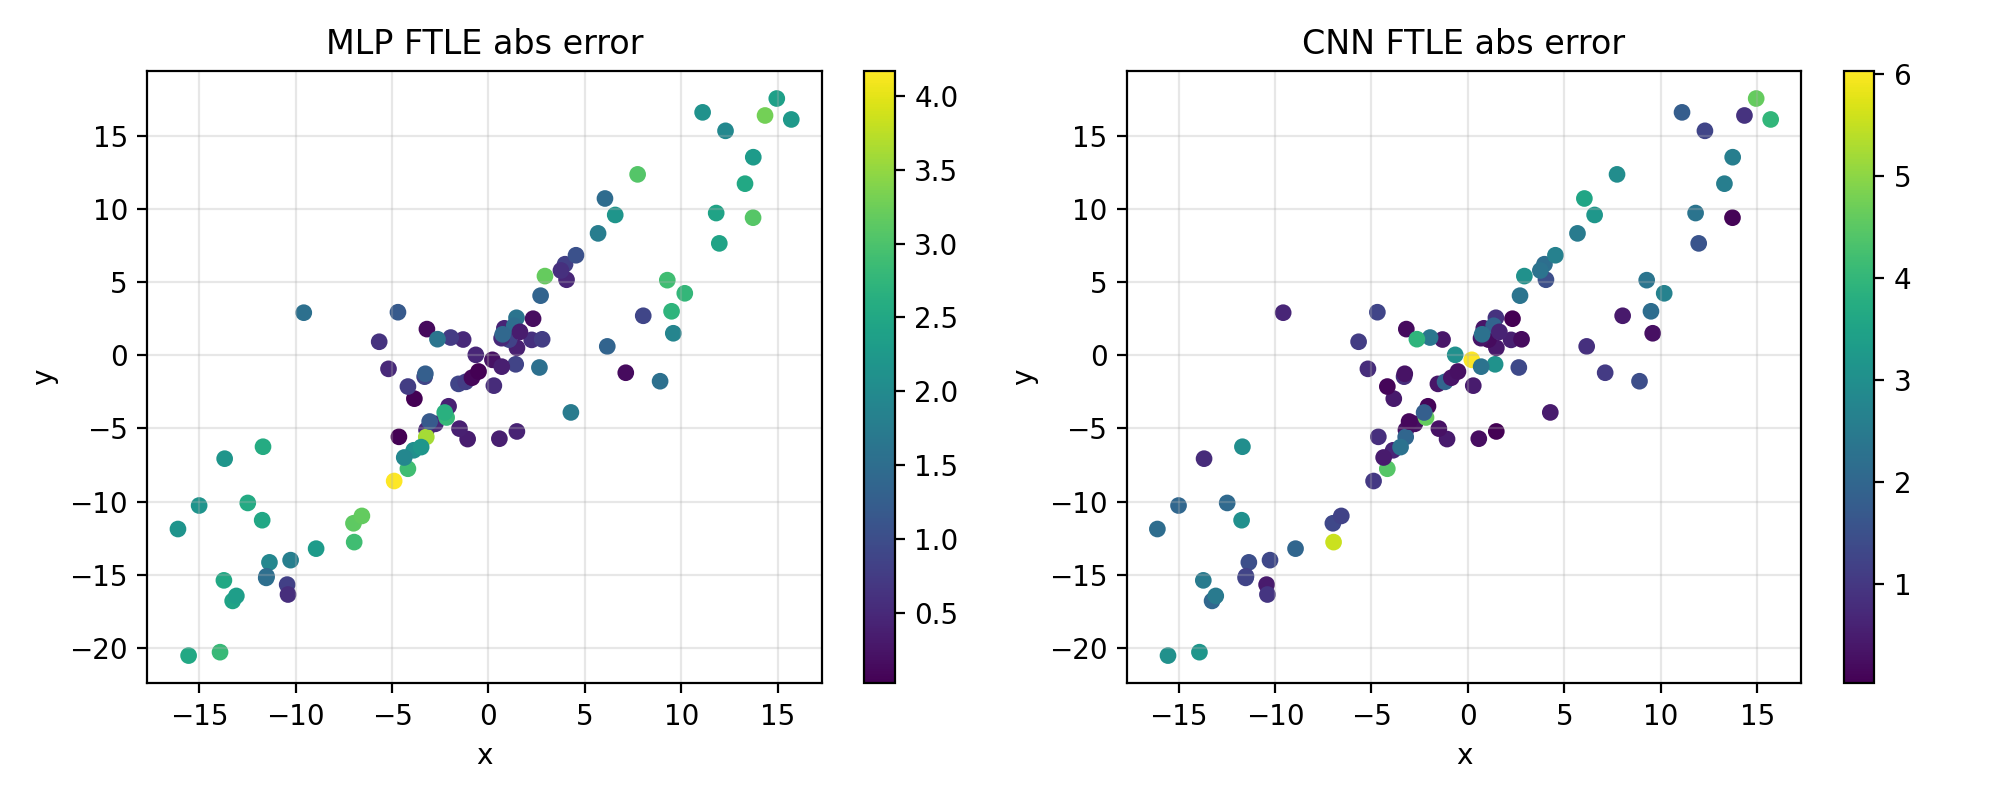

In [33]:
show_image('figures/14_ftle_l63_100k_hist.png', width=750)
show_image('figures/14_ftle_l63_100k_scatter.png', width=750)
show_image('figures/14_ftle_l63_100k_error_on_attractor.png', width=900)


### FTLE interpretation

The `physical` row has zero bias, zero MAE, zero RMSE, and correlation one because it is compared with itself. The important rows are the emulator rows.

The FTLE results show that even when a model captures a plausible global Lyapunov exponent, the local instability field can still be biased and weakly correlated with the physical FTLE field. This means the emulator may reproduce an average instability rate while failing to identify the correct unstable regions of the attractor.


## 8. Cross-run reproducibility across machines

The project was packaged so that several students can run the same pipeline on different machines. Each run creates a compact result ZIP:

```bash
python tools/collect_final_results.py --run-id YOUR_RUN_ID
```

For sharing both the compact result and key logs:

```bash
tar -czf lorenz96_results_YOUR_RUN_ID_fullshare.tar.gz \
  lorenz96_project_final_package/collected_runs/lorenz96_results_YOUR_RUN_ID.zip \
  lorenz96_project_final_package/reports/*.log \
  lorenz96_project_final_package/reports/12_train_100k_models_summary_clean.txt \
  lorenz96_project_final_package/reports/13_rollout_100k_summary.txt \
  lorenz96_project_final_package/reports/14_lyapunov_100k_table.txt \
  lorenz96_project_final_package/reports/14_ftle_l63_100k_summary.txt
```

The final report can compare the JUNO run with additional runs from other accounts or machines.


## 9. Final scientific conclusions

1. **Tendency learning is better conditioned than direct next-state prediction.**  
   In one-step-equivalent error, tendency models are consistently strong because they learn the physical increment/rate rather than a near-identity map.

2. **The periodic CNN inductive bias is important for Lorenz-96.**  
   Lorenz-96 has a periodic spatial structure, and the CNN uses that structure directly. This improves one-step accuracy and autoregressive stability.

3. **One-step error is not enough.**  
   Some models with acceptable one-step error fail during autoregressive rollout. The Lorenz-96 MLP next-state emulator is the clearest negative example.

4. **Lyapunov diagnostics reveal dynamical fidelity.**  
   Models that look similar in short-term RMSE can have very different leading Lyapunov exponents.

5. **FTLE diagnostics are stricter than global Lyapunov exponents.**  
   Even when the global instability scale is reasonable, the emulator can misplace local unstable regions on the attractor.

6. **Main answer to the project question.**  
   The ML emulators reproduce short-term trajectories and, with the right target/architecture, can approximate some global chaotic diagnostics. However, they do not fully reproduce the local instability structure of the physical systems. The CNN bias helps strongly for Lorenz-96, but local FTLE errors remain substantial.


## 10. Limitations and honest negative results

- The models are trained with one-step supervised learning only; no multi-step or physics-informed loss is used.
- The Lyapunov estimates for neural emulators are finite-time estimates over limited rollout lengths, so they should be interpreted as approximate diagnostics rather than exact asymptotic values.
- The Lorenz-63 CNN is included for symmetry but is not as physically motivated as the Lorenz-96 CNN, because L63 does not have a spatially periodic state.
- Direct next-state prediction can be unstable in autoregressive mode, especially for Lorenz-96 MLP.
- FTLE maps show that local instability is not robustly captured, even by the best one-step models.

These limitations are scientifically useful because they show where simple neural emulation succeeds and where it fails for chaotic dynamics.


## 11. Files used by this notebook

Key reports:

- `reports/12_train_100k_models_summary_clean.csv`
- `reports/13_rollout_100k_summary.csv`
- `reports/13_prediction_horizon_100k.csv`
- `reports/14_lyapunov_100k_table.csv`
- `reports/14_ftle_l63_100k_summary.csv`

Key figures:

- `figures/l63_100k_rollout_rmse_all.png`
- `figures/l96_100k_rollout_rmse_all.png`
- `figures/13_prediction_horizon_100k.png`
- `figures/l63_100k_power_spectrum_best.png`
- `figures/l96_100k_power_spectrum_best.png`
- `figures/14_lyapunov_100k_bar.png`
- `figures/14_ftle_l63_100k_hist.png`
- `figures/14_ftle_l63_100k_scatter.png`
- `figures/14_ftle_l63_100k_error_on_attractor.png`
